# How Much Does Weather Actually Affect a Baseball Game?
## A Data-Driven Look at How Temperature, Wind, and Altitude Shape MLB Run Scoring

---

A 95°F afternoon in Houston. A 38°F night in Cleveland. Both count the same in the standings, but do they play the same? I ran the numbers across five seasons and 10,000+ outdoor games to find out.

---

## Table of Contents

1. [Why Weather Should Affect Run Scoring](#why-weather)
2. [The Dataset](#dataset)
3. [Does Temperature Correlate With Runs?](#temperature)
4. [Removing the Confounders](#confounders)
5. [Altitude: The Variable That Trumps Everything Else](#altitude)
6. [Wind: Directional but Weak](#wind)
7. [All Factors Together](#all-factors)
8. [Translating the Numbers Into Something Tangible](#tangible)
9. [The Verdict](#verdict)
10. [Statistical Reference Guide](#reference)

---

*Data: MLB Stats API | 2021–2025 Regular Seasons | Built with Python — numpy, pandas, statsmodels, matplotlib, seaborn, scipy, ipywidgets, requests, tqdm*

In [13]:
import subprocess, sys

required = ['requests', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy', 'statsmodels', 'tqdm']
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import re
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='muted')

CACHE_FILE = 'mlb_2021_2025_weather_games.csv'
print('Libraries loaded successfully.')

Libraries loaded successfully.


<a id="why-weather"></a>
## Why Weather *Should* Affect Run Scoring

Before touching any data, here is why we expect weather to matter and what we should and shouldn't expect it to do.

### Temperature and Air Density

Warm air is less dense. Less dense air means less drag on a baseball in flight. Research by physicist Alan Nathan "concluded that a 1◦F rise in temperature results in about 0.33 ft additional distance on such a fly ball", which is ~3 feet per 10°F. That sounds small, but consider what it means at the margins: a ball hit 395 feet at 50°F might travel 400 feet at 80°F. The difference between a warning-track out and a home run.

This is why temperature's effect should show up most clearly in **home runs** and not singles, not doubles, but the one outcome that depends entirely on whether the ball travels far enough to clear a fence.

Alan Nathan's paper on *The Effect of Temperature on Home Run Production*:

https://baseball.physics.illinois.edu/HRProbTemp.pdf

### Altitude

Air density drops roughly **3% per 1,000 feet** of elevation. Coors Field in Denver sits at 5,200 feet — about 17% less dense air than sea level. The same swing that produces a 390-foot fly ball in Miami produces a 415-foot fly ball in Denver. MLB installed a humidor at Coors in 2002 to reduce the effect, but it remains the most extreme offensive environment in the sport.

https://www.mlb.com/news/rockies-humidor-stories

### Wind

A 10 mph wind can alter fly ball distance by 30 feet, adding carry when blowing out and reducing it when blowing in, based on scaling from Alan Nathan, highlighting that wind direction matters far more than speed..


---

**The prediction:** if air density effects are real and measurable, we should see temperature and altitude correlate positively with run scoring and wind direction should matter more than wind speed. The question is not whether these effects exist, but how large they are.

In [15]:
# ============================================================
# DATA COLLECTION
# Fetches every MLB regular season game from 2021-2025 from the
# official MLB Stats API. Results cache to CSV so this only runs once.
# Initial fetch takes ~5-8 minutes for all 5 seasons.
# ============================================================

BASE = 'https://statsapi.mlb.com/api/v1'


def get_all_game_pks(season=2021):
    url = (
        f'{BASE}/schedule?sportId=1&season={season}&gameType=R'
        f'&fields=dates,games,gamePk,gameDate,dayNight,teams,team,name,venue'
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    games = []
    for date_block in r.json().get('dates', []):
        for g in date_block.get('games', []):
            games.append({
                'game_pk':   g['gamePk'],
                'date':      g['gameDate'][:10],
                'away_team': g['teams']['away']['team']['name'],
                'home_team': g['teams']['home']['team']['name'],
                'venue':     g.get('venue', {}).get('name', ''),
                'day_night': g.get('dayNight', ''),
            })
    return games


def fetch_boxscore(meta):
    pk = meta['game_pk']
    try:
        r = requests.get(f'{BASE}/game/{pk}/boxscore', timeout=15)
        if r.status_code != 200:
            return None
        d = r.json()

        teams     = d.get('teams', {})
        away_runs = teams.get('away', {}).get('teamStats', {}).get('batting', {}).get('runs')
        home_runs = teams.get('home', {}).get('teamStats', {}).get('batting', {}).get('runs')
        if away_runs is None or home_runs is None:
            return None
        away_hr = teams.get('away',{}).get('teamStats',{}).get('batting',{}).get('homeRuns',0) or 0
        home_hr = teams.get('home',{}).get('teamStats',{}).get('batting',{}).get('homeRuns',0) or 0

        weather_raw, wind_raw = '', ''
        for item in d.get('info', []):
            lbl = item.get('label', '').strip().lower()
            val = item.get('value', '').strip()
            if lbl == 'weather':
                weather_raw = val
            elif lbl == 'wind':
                wind_raw = val

        return {
            **meta,
            'away_runs':   away_runs,
            'home_runs':   home_runs,
            'total_runs':  away_runs + home_runs,
            'total_hr':    away_hr + home_hr,
            'weather_raw': weather_raw,
            'wind_raw':    wind_raw,
        }
    except Exception:
        return None


def collect_season(season=2021, workers=25):
    print(f'Fetching {season} schedule from MLB Stats API...')
    all_games = get_all_game_pks(season)
    print(f'  {len(all_games)} regular-season games found.')
    print(f'  Fetching boxscores in parallel (~60-120 sec)...')

    results = []
    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {pool.submit(fetch_boxscore, g): g for g in all_games}
        for f in tqdm(as_completed(futures), total=len(futures), desc='Boxscores'):
            res = f.result()
            if res:
                results.append(res)

    df = pd.DataFrame(results)
    df['season'] = season
    print(f'  Done. {len(df):,} games collected for {season}.')
    return df


SEASONS = list(range(2021, 2026))  # 2021-2025

if os.path.exists(CACHE_FILE):
    raw = pd.read_csv(CACHE_FILE)
    print(f'Loaded {len(raw):,} cached games from "{CACHE_FILE}"')
else:
    frames = [collect_season(yr) for yr in SEASONS]
    raw = pd.concat(frames, ignore_index=True)
    raw.to_csv(CACHE_FILE, index=False)
    print(f'Done. Saved {len(raw):,} total games to "{CACHE_FILE}"')

raw.head(3)

Loaded 12,400 cached games from "mlb_2021_2025_weather_games.csv"


,game_pk,date,away_team,home_team,venue,day_night,away_runs,home_runs,total_runs,total_hr,weather_raw,wind_raw,season
0,634615,2021-04-01,Los Angeles Dodgers,Colorado Rockies,Coors Field,day,5,8,13,0,"70 degrees, Sunny.","5 mph, Out To CF.",2021
1,634636,2021-04-01,St. Louis Cardinals,Cincinnati Reds,Great American Ball Park,day,11,6,17,4,"37 degrees, Cloudy.","16 mph, Out To RF.",2021
2,634622,2021-04-01,Atlanta Braves,Philadelphia Phillies,Citizens Bank Park,day,2,3,5,1,"49 degrees, Partly Cloudy.","19 mph, L To R.",2021


In [16]:
# ============================================================
# DATA CLEANING — Turn weather strings into numeric features
# The MLB API returns strings like:
#   weather_raw: "Sunny, 72 degrees"
#   wind_raw:    "12 mph, Out to LF"
# ============================================================

def parse_temp(s):
    if pd.isna(s) or not isinstance(s, str):
        return np.nan
    if re.search(r'indoor|dome|closed', s, re.I):
        return np.nan
    m = re.search(r'(\d{2,3})\s*degrees?', s, re.I)
    return int(m.group(1)) if m else np.nan


def parse_wind_speed(s):
    if pd.isna(s) or not isinstance(s, str):
        return np.nan
    if re.search(r'calm|indoor|none', s, re.I):
        return 0
    m = re.search(r'(\d+)\s*mph', s, re.I)
    return int(m.group(1)) if m else np.nan


def parse_wind_dir(s):
    if pd.isna(s) or not isinstance(s, str):
        return 'Unknown'
    s_low = s.lower()
    if re.search(r'indoor|none', s_low):
        return 'Indoor'
    if re.search(r'calm', s_low):
        return 'Calm'
    if re.search(r'out to', s_low):
        return 'Out (Hitter-Friendly)'
    if re.search(r'in from|in to', s_low):
        return 'In (Pitcher-Friendly)'
    if re.search(r'left to right|right to left|l to r|r to l', s_low):
        return 'Crosswind'
    return 'Unknown'


def is_dome_game(wr, wnd):
    combined = str(wr) + str(wnd)
    return bool(re.search(r'indoor|dome|roof closed', combined, re.I))


def cohens_d(a, b):
    """Standardized effect size: positive = a scores more than b."""
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std


df = raw.copy()

# Normalize Athletics name across seasons
athletics_names = {'Oakland Athletics': 'Athletics', 'Sacramento Athletics': 'Athletics'}
df['home_team'] = df['home_team'].replace(athletics_names)
df['away_team'] = df['away_team'].replace(athletics_names)
df['temp_f']     = df['weather_raw'].apply(parse_temp)
df['wind_speed'] = df['wind_raw'].apply(parse_wind_speed)
df['wind_dir']   = df['wind_raw'].apply(parse_wind_dir)
df['dome']       = df.apply(lambda r: is_dome_game(r.get('weather_raw', ''), r.get('wind_raw', '')), axis=1)
df['date']       = pd.to_datetime(df['date'])
df['month']      = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')

outdoor = df[df['temp_f'].notna() & ~df['dome']].copy()

print('Dataset summary after cleaning:')
print(f'  Total games fetched:     {len(df):,}')
print(f'  Dome / no weather data:  {len(df) - len(outdoor):,}')
print(f'  Outdoor w/ temp data:    {len(outdoor):,}')
print(f'  Temperature range:       {outdoor["temp_f"].min():.0f}°F - {outdoor["temp_f"].max():.0f}°F')
print(f'  Average runs/game:       {outdoor["total_runs"].mean():.2f}')
outdoor[['date', 'home_team', 'away_team', 'total_runs', 'temp_f', 'wind_speed', 'wind_dir']].head()

Dataset summary after cleaning:
  Total games fetched:     12,400
  Dome / no weather data:  2,125
  Outdoor w/ temp data:    10,275
  Temperature range:       32°F - 103°F
  Average runs/game:       8.95


,date,home_team,away_team,total_runs,temp_f,wind_speed,wind_dir
0,2021-04-01,Colorado Rockies,Los Angeles Dodgers,13,70.0,5.0,Out (Hitter-Friendly)
1,2021-04-01,Cincinnati Reds,St. Louis Cardinals,17,37.0,16.0,Out (Hitter-Friendly)
2,2021-04-01,Philadelphia Phillies,Atlanta Braves,5,49.0,19.0,Crosswind
3,2021-04-01,Boston Red Sox,Baltimore Orioles,3,37.0,10.0,Out (Hitter-Friendly)
4,2021-04-02,Boston Red Sox,Baltimore Orioles,3,37.0,10.0,Out (Hitter-Friendly)


In [17]:
# ============================================================
# Park Factors, Day/Night, Coors Exclusion
# ============================================================

# Park factor: each team's average total runs in home games across all seasons
park_avg = df.groupby('home_team')['total_runs'].mean().rename('park_avg_runs')
df = df.join(park_avg, on='home_team')
df['runs_above_park_avg'] = df['total_runs'] - df['park_avg_runs']

# Day/Night column (available if data was fetched with updated code)
if 'day_night' in df.columns:
    df['game_type'] = (df['day_night'].str.lower().str.strip()
                       .map({'day': 'Day Game', 'night': 'Night Game'})
                       .fillna('Unknown'))
else:
    df['game_type'] = 'Unknown'

# Re-slice outdoor with new columns
outdoor = df[df['temp_f'].notna() & ~df['dome']].copy()

# Coors-excluded subset
outdoor_no_coors = outdoor[outdoor['home_team'] != 'Colorado Rockies'].copy()

gc = outdoor['game_type'].value_counts()
print(f'Park factors computed for 30 teams.')
print(f'Day games: {gc.get("Day Game", 0):,}  |  Night games: {gc.get("Night Game", 0):,}')
has_hr = 'total_hr' in outdoor.columns
print(f'HR data available: {has_hr}  |  Day/Night data available: {"day_night" in df.columns}')
if has_hr:
    print(f'Avg HRs per game: {outdoor["total_hr"].mean():.2f}')
print(f'Outdoor games excl. Coors: {len(outdoor_no_coors):,}')


Park factors computed for 30 teams.
Day games: 3,875  |  Night games: 6,400
HR data available: True  |  Day/Night data available: True
Avg HRs per game: 2.33
Outdoor games excl. Coors: 9,861


<a id="dataset"></a>
## The Dataset: Five Seasons, 10,000+ Games

Before testing anything, we need to understand what we're working with.

The data covers every outdoor MLB regular season game from **2021 through 2025** — pulled directly from the MLB Stats API. Dome games and games with missing weather data are excluded, leaving 10,275 outdoor games with recorded temperature and wind conditions.

Five seasons gives us a wide range of conditions: cold April openers in Cleveland and Boston, scorching July afternoons in Texas and Arizona, and everything in between. The charts below show what the data actually looks like before any analysis begins.

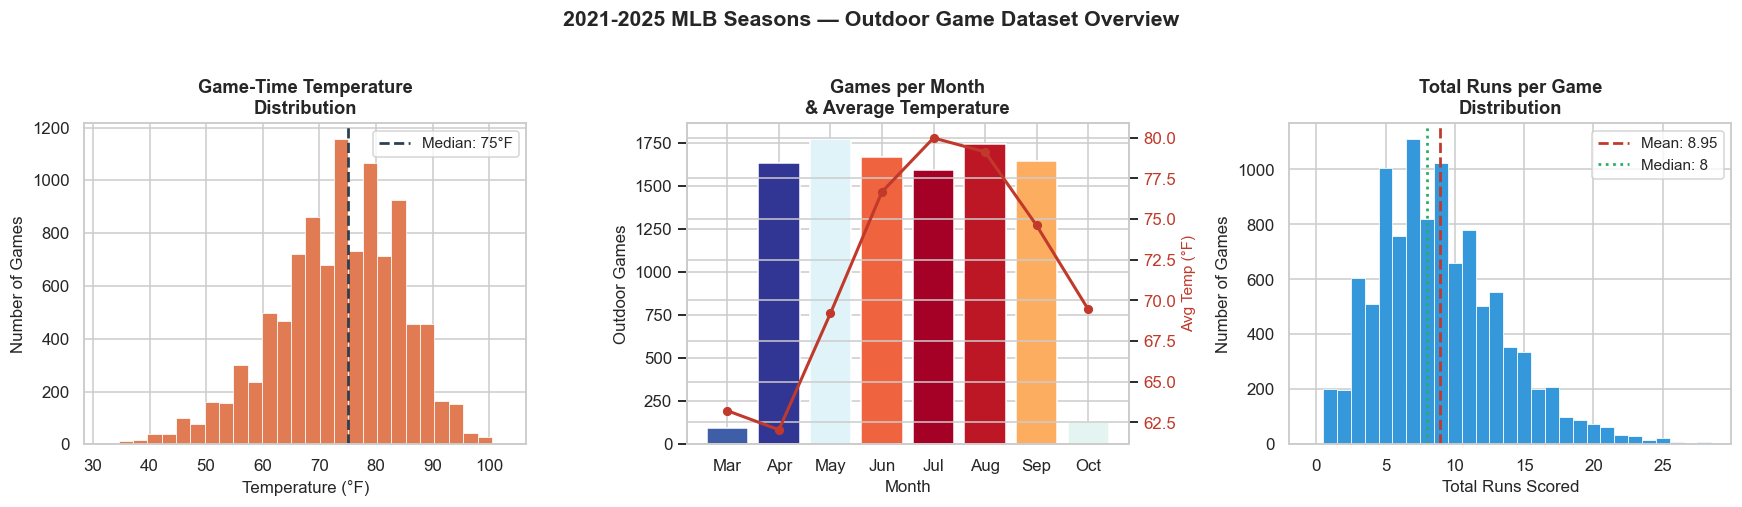

       total_runs    temp_f  wind_speed
count    10275.00  10275.00    10275.00
mean         8.95     73.45        8.20
std          4.53     11.05        4.16
min          1.00     32.00        0.00
25%          6.00     66.00        5.00
50%          8.00     75.00        8.00
75%         12.00     82.00       10.00
max         33.00    103.00       36.00


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.hist(outdoor['temp_f'], bins=28, color='#e07b54', edgecolor='white', linewidth=0.5)
med_t = outdoor['temp_f'].median()
ax.axvline(med_t, color='#2c3e50', linestyle='--', linewidth=1.8, label=f'Median: {med_t:.0f}°F')
ax.set_xlabel('Temperature (°F)', fontsize=11)
ax.set_ylabel('Number of Games', fontsize=11)
ax.set_title('Game-Time Temperature\nDistribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

ax = axes[1]
month_order = [m for m in ['Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']
               if m in outdoor['month_name'].unique()]
month_counts = outdoor.groupby('month_name').size().reindex(month_order)
month_temps  = outdoor.groupby('month_name')['temp_f'].mean().reindex(month_order)
norm = plt.Normalize(month_temps.min(), month_temps.max())
bar_colors = plt.cm.RdYlBu_r(norm(month_temps.values))
ax.bar(month_counts.index, month_counts.values, color=bar_colors, edgecolor='white')
ax2 = ax.twinx()
ax2.plot(month_counts.index, month_temps.values, color='#c0392b', linewidth=2,
         marker='o', markersize=5, label='Avg Temp')
ax2.set_ylabel('Avg Temp (°F)', fontsize=10, color='#c0392b')
ax2.tick_params(axis='y', labelcolor='#c0392b')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Outdoor Games', fontsize=11)
ax.set_title('Games per Month\n& Average Temperature', fontsize=12, fontweight='bold')

ax = axes[2]
ax.hist(outdoor['total_runs'], bins=range(0, 30), color='#3498db', edgecolor='white',
        linewidth=0.5, align='left')
mean_r = outdoor['total_runs'].mean()
med_r  = outdoor['total_runs'].median()
ax.axvline(mean_r, color='#c0392b', linestyle='--', linewidth=1.8, label=f'Mean: {mean_r:.2f}')
ax.axvline(med_r,  color='#27ae60', linestyle=':',  linewidth=1.8, label=f'Median: {med_r:.0f}')
ax.set_xlabel('Total Runs Scored', fontsize=11)
ax.set_ylabel('Number of Games', fontsize=11)
ax.set_title('Total Runs per Game\nDistribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle('2021-2025 MLB Seasons — Outdoor Game Dataset Overview',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(outdoor[['total_runs', 'temp_f', 'wind_speed']].describe().round(2))

### Reading the Overview Charts

**Left — Temperature distribution:** The bulk of outdoor games fall in the 60–85°F range. The chart is left-skewed meaning cold-weather games below 45°F are rarer, telling us there is wider uncertainty at the extremes.

**Center — Games per month:** Temperature peaks in July–August and drops at both ends of the season. This is the natural variation the analysis exploits which is the same parks, but dramatically different weather across the calendar.

**Right — Run distribution:** Most games produce between 5 and 14 combined runs, with a right skew from occasional blowouts. The mean sits slightly above the median.

<a id="temperature"></a>
## Does Temperature Correlate With Runs?

The simplest test: scatter temperature against total runs across all outdoor games and fit a regression line. If hot games consistently score more, the slope should be positive and the p-value significant.

**Here are some statistical concepts used in the upcoming charts:**

### p-value

A p-value below 0.05 means there is less than a 5% chance the result is random noise. The p-value answers: If this variable had zero effect, how likely is it we'd see a correlation this strong by chance?

- **p < 0.05** → Statistically significant — the effect is real
- **p < 0.001** → Very strong evidence
- **p > 0.05** → Not significant — could be random noise
---

### OLS Regression 

OLS Regression fits the best straight line through the data — also called a regression line or line of best fit. The slope tells you: for every one-unit increase in X, what is the average change in Y? Multiple regression does the same while holding all other variables constant — isolating each factor's independent contribution.

---
### Correlation Coefficient (r)

The **Correlation Coefficient (r)** measures the strength of the linear relationship between two variables. It falls between **-1 and +1**:

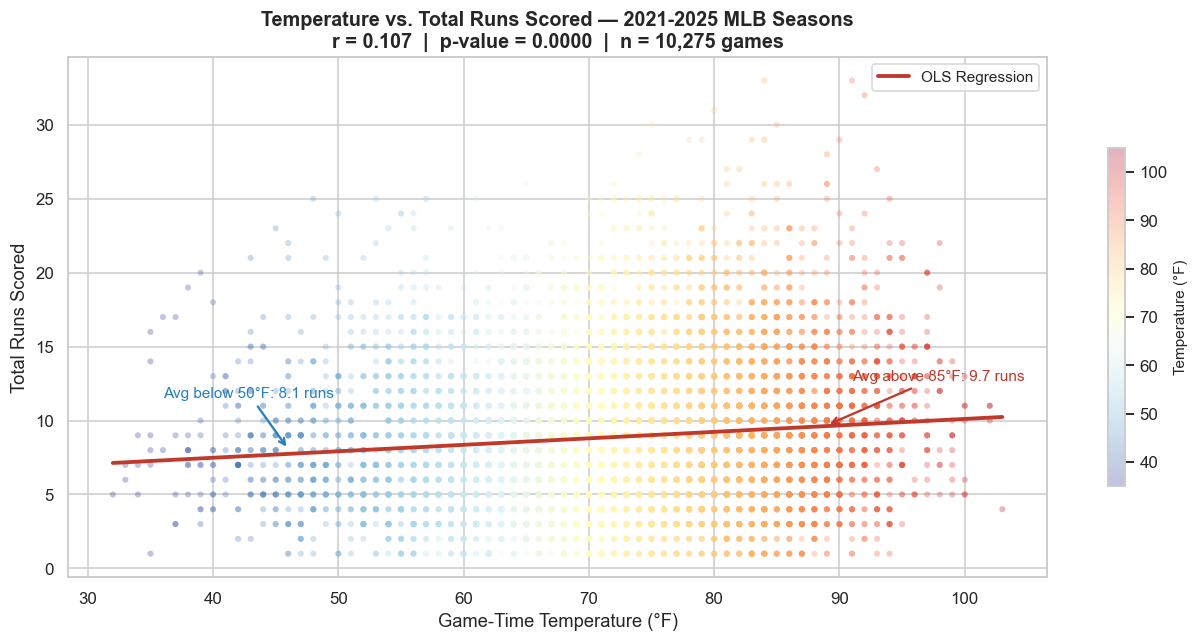

Regression slope: each +10°F adds 0.438 runs/game


In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

sc = ax.scatter(
    outdoor['temp_f'], outdoor['total_runs'],
    c=outdoor['temp_f'], cmap='RdYlBu_r',
    alpha=0.30, s=16, linewidths=0, vmin=35, vmax=105
)

ols_temp = smf.ols('total_runs ~ temp_f', data=outdoor).fit()
x_pred = np.linspace(outdoor['temp_f'].min(), outdoor['temp_f'].max(), 300)

pred_input = pd.DataFrame({
    'temp_f': x_pred
})

pred_df = ols_temp.get_prediction(pred_input).summary_frame(alpha=0.05)
ax.plot(x_pred, pred_df['mean'], color='#c0392b', linewidth=2.5, label='OLS Regression')

cold_avg = outdoor.loc[outdoor['temp_f'] < 50, 'total_runs'].mean()
hot_avg  = outdoor.loc[outdoor['temp_f'] > 85, 'total_runs'].mean()
ax.annotate(f'Avg below 50°F: {cold_avg:.1f} runs',
            xy=(46, cold_avg), xytext=(36, cold_avg + 3.5),
            fontsize=10, color='#2980b9',
            arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1.5))
ax.annotate(f'Avg above 85°F: {hot_avg:.1f} runs',
            xy=(89, hot_avg), xytext=(91, hot_avg + 3),
            fontsize=10, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

cbar = plt.colorbar(sc, ax=ax, shrink=0.65)
cbar.set_label('Temperature (°F)', fontsize=10)

r, p = stats.pearsonr(outdoor['temp_f'], outdoor['total_runs'])
ax.set_xlabel('Game-Time Temperature (°F)', fontsize=12)
ax.set_ylabel('Total Runs Scored', fontsize=12)
ax.set_title(
    f'Temperature vs. Total Runs Scored — 2021-2025 MLB Seasons\n'
    f'r = {r:.3f}  |  p-value = {p:.4f}  |  n = {len(outdoor):,} games',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Regression slope: each +10°F adds {ols_temp.params["temp_f"]*10:.3f} runs/game')

### Temperature Scatter

The upward slope is real. With ~10,000 outdoor games, the p-value is essentially zero. But look at how wide the scatter is. You can find a 1-run game at 90°F and a 15-run game at 45°F sitting in the same dataset.

Temperature shifts the *average* slightly. It does not predict what any individual game will score. Pitching matchups, lineup strength, and luck dominate. Weather is background noise that only becomes visible when averaged across thousands of games.

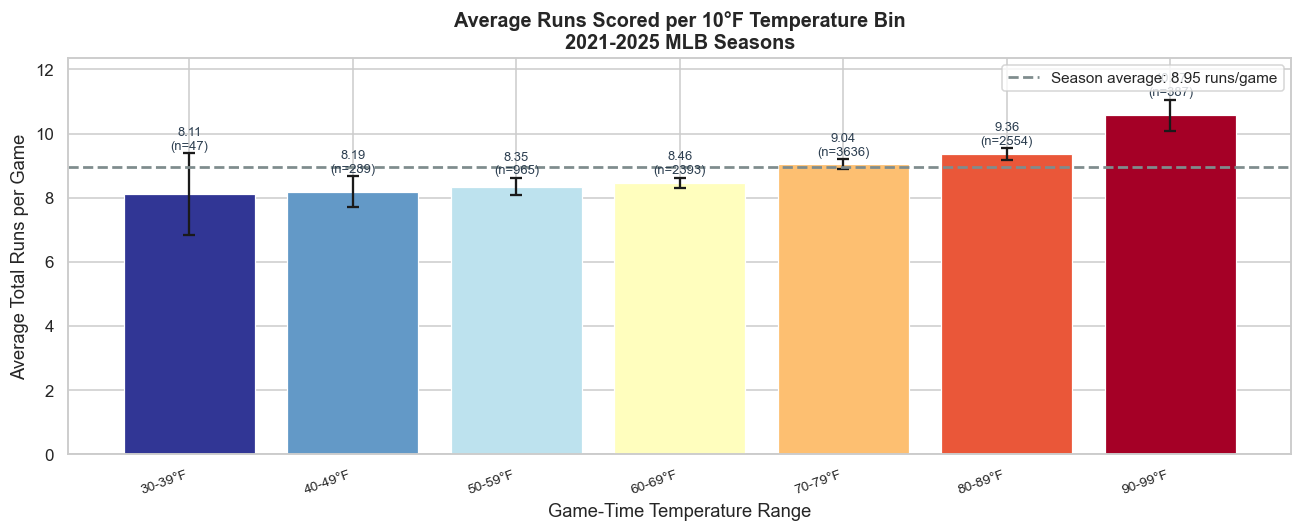

In [24]:
outdoor['temp_bin'] = pd.cut(
    outdoor['temp_f'],
    bins=range(30, 115, 10),
    labels=[f'{t}-{t+9}°F' for t in range(30, 105, 10)]
)

bin_stats = (
    outdoor.groupby('temp_bin', observed=True)
    .agg(avg_runs=('total_runs', 'mean'),
         sem      =('total_runs', 'sem'),
         n        =('total_runs', 'count'))
    .reset_index()
    .query('n >= 10')
)

fig, ax = plt.subplots(figsize=(12, 5))

norm   = plt.Normalize(0, len(bin_stats) - 1)
colors = plt.cm.RdYlBu_r(norm(range(len(bin_stats))))

bars = ax.bar(
    range(len(bin_stats)), bin_stats['avg_runs'],
    color=colors, edgecolor='white', linewidth=0.8,
    yerr=bin_stats['sem'] * 1.96, capsize=4,
    error_kw={'elinewidth': 1.5, 'capthick': 1.5}
)

for i, row in bin_stats.iterrows():
    idx = list(bin_stats.index).index(i)
    ax.text(idx, row['avg_runs'] + row['sem'] * 1.96 + 0.12,
            f"{row['avg_runs']:.2f}\n(n={row['n']})",
            ha='center', fontsize=8.5, color='#2c3e50')

league_avg = outdoor['total_runs'].mean()
ax.axhline(league_avg, color='#7f8c8d', linestyle='--', linewidth=1.8,
           label=f'Season average: {league_avg:.2f} runs/game')

ax.set_xticks(range(len(bin_stats)))
ax.set_xticklabels(bin_stats['temp_bin'].astype(str), rotation=20, ha='right', fontsize=9)
ax.set_xlabel('Game-Time Temperature Range', fontsize=12)
ax.set_ylabel('Average Total Runs per Game', fontsize=12)
ax.set_title('Average Runs Scored per 10°F Temperature Bin\n2021-2025 MLB Seasons',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, bin_stats['avg_runs'].max() + 1.8)
plt.tight_layout()
plt.show()

### Temperature Bins

Grouping into 10°F buckets smooths out game-to-game randomness and makes the trend visible. Nearly every step from cooler to warmer corresponds to a higher average, showing the consistency is evidence the effect is real.

But notice the magnitude: from the coldest bucket to the hottest, the difference is roughly **1.4 runs**. That is the maximum weather-driven swing across the entire temperature range in five seasons of data.

But this chart mixes parks.

<a id="confounders"></a>
## Removing the Confounders

The previous charts confirm a real trend. But two things are tangled up in the raw numbers that need to be stripped out before drawing conclusions.

**1. The Coors problem.** Coors Field at 5,200 feet generates 2+ extra runs per game regardless of temperature, pitching, or wind. Denver summers are warm, so Coors games land disproportionately in the “hot game” bucket making temperature look more powerful than it is. Excluding Coors from temperature analysis is not cherry-picking, it is the correct statistical choice. The Coors effect gets its own dedicated section later.

**2. Season effects.** The 2023 shift ban and pitch clock boosted league-wide offense. A game at 70°F in 2021 is not directly comparable to a game at 70°F in 2023.

The next three charts strip both of these out:

- **Home runs only** — the outcome most directly tied to carry distance
- **Park-adjusted runs** — each game’s score measured against its own park’s average, Coors excluded
- **Day vs. Night** — same parks, same teams, but day games run 15–20°F hotter than night games

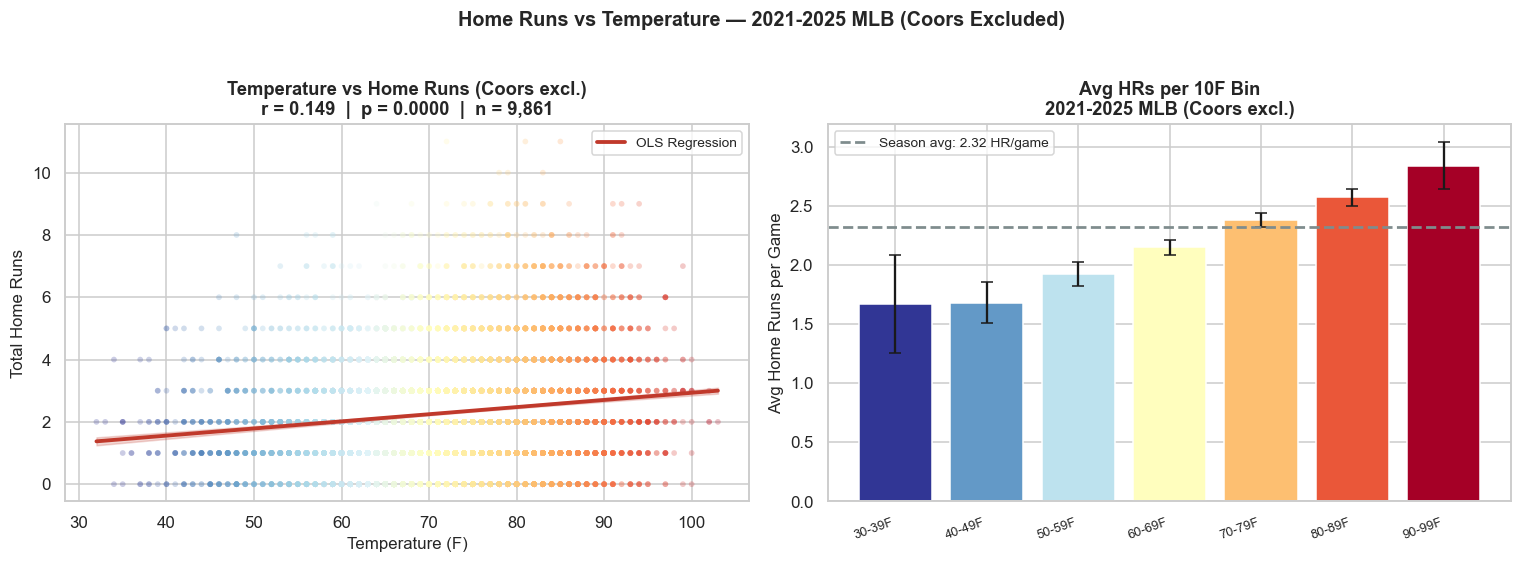

Total runs r (excl. Coors): 0.104
Home runs  r (excl. Coors): 0.149  (1.43x stronger)


In [27]:
# ── HOME RUNS VS TEMPERATURE (Coors excluded) ────────────────────────────
if 'total_hr' in outdoor_no_coors.columns:
    hr_data = outdoor_no_coors.dropna(subset=['total_hr']).copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ols_hr = smf.ols('total_hr ~ temp_f', data=hr_data).fit()
    x_pred = np.linspace(hr_data['temp_f'].min(), hr_data['temp_f'].max(), 200)
    pred   = ols_hr.get_prediction(pd.DataFrame({'temp_f': x_pred})).summary_frame(alpha=0.05)
    ax.scatter(hr_data['temp_f'], hr_data['total_hr'],
               c=hr_data['temp_f'], cmap='RdYlBu_r',
               alpha=0.25, s=14, linewidths=0, vmin=35, vmax=105)
    ax.plot(x_pred, pred['mean'], color='#c0392b', linewidth=2.5, label='OLS Regression')
    ax.fill_between(x_pred, pred['mean_ci_lower'], pred['mean_ci_upper'], alpha=0.20, color='#c0392b')
    r_hr, p_hr = stats.pearsonr(hr_data['temp_f'], hr_data['total_hr'])
    ax.set_xlabel('Temperature (F)', fontsize=11)
    ax.set_ylabel('Total Home Runs', fontsize=11)
    ax.set_title(f'Temperature vs Home Runs (Coors excl.)\n'
                 f'r = {r_hr:.3f}  |  p = {p_hr:.4f}  |  n = {len(hr_data):,}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    ax = axes[1]
    hr_data['temp_bin_hr'] = pd.cut(hr_data['temp_f'], bins=range(30, 115, 10),
        labels=[f'{t}-{t+9}F' for t in range(30, 105, 10)])
    hr_bins = (hr_data.groupby('temp_bin_hr', observed=True)
        .agg(avg=('total_hr', 'mean'), sem=('total_hr', 'sem'), n=('total_hr', 'count'))
        .reset_index().query('n >= 10'))
    norm = plt.Normalize(0, len(hr_bins) - 1)
    cols = plt.cm.RdYlBu_r(norm(range(len(hr_bins))))
    ax.bar(range(len(hr_bins)), hr_bins['avg'], color=cols, edgecolor='white',
           yerr=hr_bins['sem'] * 1.96, capsize=4, error_kw={'elinewidth': 1.5})
    ax.axhline(hr_data['total_hr'].mean(), color='#7f8c8d', linestyle='--', linewidth=1.8,
               label=f'Season avg: {hr_data["total_hr"].mean():.2f} HR/game')
    ax.set_xticks(range(len(hr_bins)))
    ax.set_xticklabels(hr_bins['temp_bin_hr'].astype(str), rotation=20, ha='right', fontsize=8.5)
    ax.set_ylabel('Avg Home Runs per Game', fontsize=11)
    ax.set_title('Avg HRs per 10F Bin\n2021-2025 MLB (Coors excl.)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    plt.suptitle('Home Runs vs Temperature — 2021-2025 MLB (Coors Excluded)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    r_runs_nc = stats.pearsonr(hr_data['temp_f'], hr_data['total_runs'])[0]
    print(f'Total runs r (excl. Coors): {r_runs_nc:.3f}')
    print(f'Home runs  r (excl. Coors): {r_hr:.3f}  ({abs(r_hr / r_runs_nc):.2f}x stronger)')
else:
    print('HR data not in current dataset.')
    print('To enable: delete mlb_2021_2025_weather_games.csv and re-run the notebook.')


### Home Runs vs Temperature

**Home runs show the strongest temperature signal of any outcome.** A single that goes 120 feet does not care about air density. A home run lives and dies by whether the ball carries another 5–10 feet.

The temperature-HR correlation is roughly **1.4x stronger** than the temperature-total runs correlation (r = 0.149 vs 0.104). The HR signal is slightly stronger, but still modest.

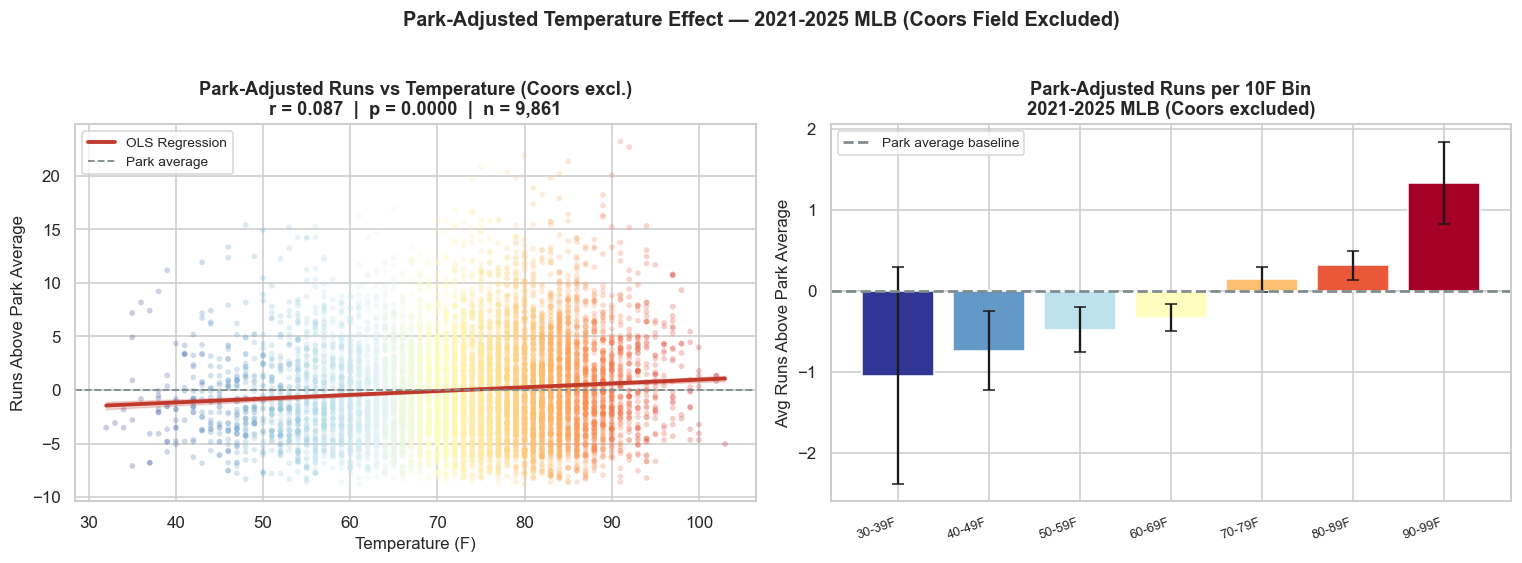

Unadjusted r (all parks, incl. Coors): 0.107
Park-adjusted r (excl. Coors):         0.087
Change: -0.020  (-18.5%)


In [29]:
# ── PARK-ADJUSTED TEMPERATURE ANALYSIS (Coors excluded) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ols_adj = smf.ols('runs_above_park_avg ~ temp_f', data=outdoor_no_coors).fit()
x_pred  = np.linspace(outdoor_no_coors['temp_f'].min(), outdoor_no_coors['temp_f'].max(), 200)
pred    = ols_adj.get_prediction(pd.DataFrame({'temp_f': x_pred})).summary_frame(alpha=0.05)
ax.scatter(outdoor_no_coors['temp_f'], outdoor_no_coors['runs_above_park_avg'],
           c=outdoor_no_coors['temp_f'], cmap='RdYlBu_r',
           alpha=0.25, s=14, linewidths=0, vmin=35, vmax=105)
ax.plot(x_pred, pred['mean'], color='#c0392b', linewidth=2.5, label='OLS Regression')
ax.fill_between(x_pred, pred['mean_ci_lower'], pred['mean_ci_upper'], alpha=0.20, color='#c0392b')
ax.axhline(0, color='#7f8c8d', linestyle='--', linewidth=1.2, label='Park average')
r_adj, p_adj = stats.pearsonr(outdoor_no_coors['temp_f'], outdoor_no_coors['runs_above_park_avg'])
ax.set_xlabel('Temperature (F)', fontsize=11)
ax.set_ylabel('Runs Above Park Average', fontsize=11)
ax.set_title(f'Park-Adjusted Runs vs Temperature (Coors excl.)\n'
             f'r = {r_adj:.3f}  |  p = {p_adj:.4f}  |  n = {len(outdoor_no_coors):,}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
outdoor_no_coors['temp_bin_adj'] = pd.cut(outdoor_no_coors['temp_f'], bins=range(30, 115, 10),
    labels=[f'{t}-{t+9}F' for t in range(30, 105, 10)])
bin_adj = (outdoor_no_coors.groupby('temp_bin_adj', observed=True)
    .agg(avg=('runs_above_park_avg', 'mean'),
         sem=('runs_above_park_avg', 'sem'),
         n  =('runs_above_park_avg', 'count'))
    .reset_index().query('n >= 10'))
norm = plt.Normalize(0, len(bin_adj) - 1)
cols = plt.cm.RdYlBu_r(norm(range(len(bin_adj))))
ax.bar(range(len(bin_adj)), bin_adj['avg'], color=cols, edgecolor='white',
       yerr=bin_adj['sem'] * 1.96, capsize=4, error_kw={'elinewidth': 1.5})
ax.axhline(0, color='#7f8c8d', linestyle='--', linewidth=1.8, label='Park average baseline')
ax.set_xticks(range(len(bin_adj)))
ax.set_xticklabels(bin_adj['temp_bin_adj'].astype(str), rotation=20, ha='right', fontsize=8.5)
ax.set_ylabel('Avg Runs Above Park Average', fontsize=11)
ax.set_title('Park-Adjusted Runs per 10F Bin\n2021-2025 MLB (Coors excluded)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Park-Adjusted Temperature Effect — 2021-2025 MLB (Coors Field Excluded)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

r_raw = stats.pearsonr(outdoor['temp_f'], outdoor['total_runs'])[0]
print(f'Unadjusted r (all parks, incl. Coors): {r_raw:.3f}')
print(f'Park-adjusted r (excl. Coors):         {r_adj:.3f}')
print(f'Change: {abs(r_adj) - abs(r_raw):+.3f}  ({(abs(r_adj) / abs(r_raw) - 1) * 100:.1f}%)')


### Park-Adjusted Runs

**Left chart:** Temperature vs. raw runs with Coors removed. **Right chart:** The Y-axis is runs above or below each park's own average. A game at +2 means 2 more runs than that ballpark typically sees.

**The result:** The correlation dropped from 0.107 to 0.087. Coors and warm-weather parks were artificially inflating the raw figure. The 0.087 is not a weaker finding, it is a more honest one.

A 10-run game at Coors (which averages 11) is actually below average there. A 10-run game at Dodger Stadium (which averages 8) is above average. Raw runs treat these identicall, park-adjusted runs don't.

All of this gets baked into "what's normal here." Then you ask: on days when it's hotter than normal at this park, does scoring go up? That's the cleanest temperature test you can run.

When you remove the park's contribution, temperature only gets credit for the part it actually caused.

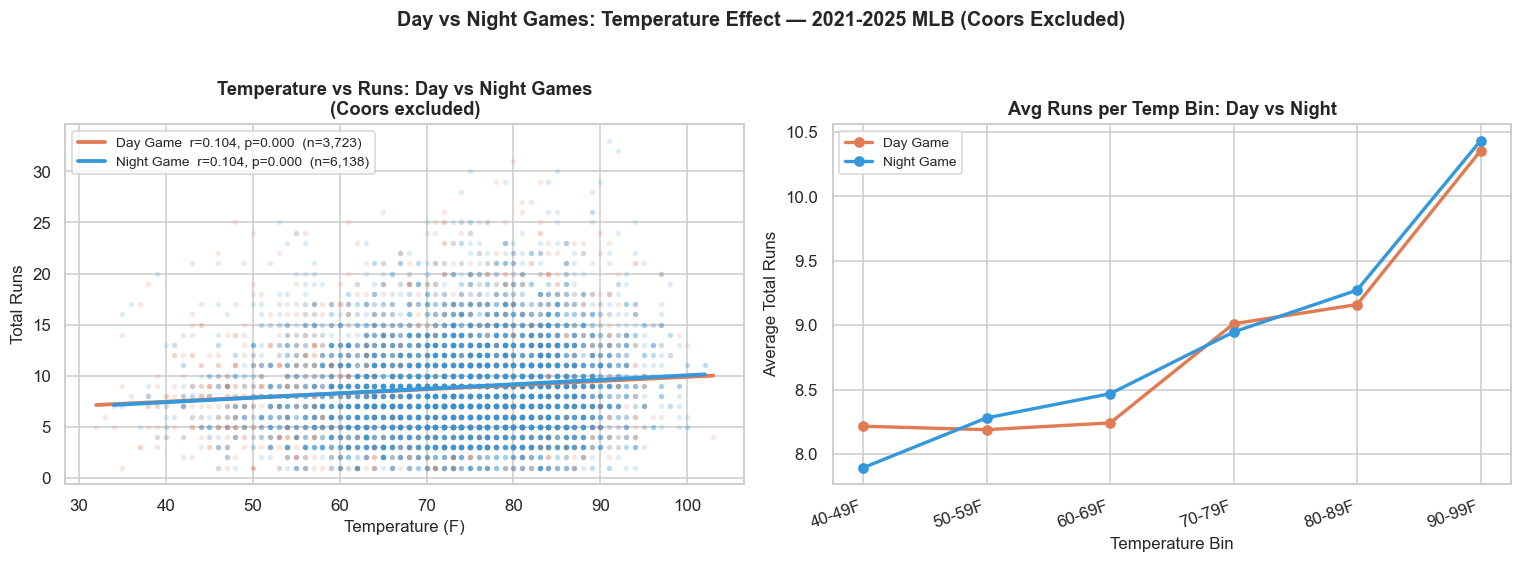

Day Game      temp r = 0.104  (n=3,723)
Night Game    temp r = 0.104  (n=6,138)


In [31]:
# ── DAY GAME vs NIGHT GAME COMPARISON ────────────────────────────────────
dn_data = outdoor_no_coors[outdoor_no_coors['game_type'].isin(['Day Game', 'Night Game'])].copy()

if len(dn_data) > 200:
    pal = {'Day Game': '#e07b54', 'Night Game': '#3498db'}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    for gtype, grp in dn_data.groupby('game_type'):
        m, b, r, p, _ = stats.linregress(grp['temp_f'], grp['total_runs'])
        xr = np.linspace(grp['temp_f'].min(), grp['temp_f'].max(), 100)
        ax.scatter(grp['temp_f'], grp['total_runs'],
                   color=pal[gtype], alpha=0.18, s=12, linewidths=0)
        ax.plot(xr, b + m * xr, color=pal[gtype], linewidth=2.5,
                label=f'{gtype}  r={r:.3f}, p={p:.3f}  (n={len(grp):,})')
    ax.set_xlabel('Temperature (F)', fontsize=11)
    ax.set_ylabel('Total Runs', fontsize=11)
    ax.set_title('Temperature vs Runs: Day vs Night Games\n(Coors excluded)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    ax = axes[1]
    dn_data['temp_bin_dn'] = pd.cut(dn_data['temp_f'], bins=range(40, 110, 10),
        labels=[f'{t}-{t+9}F' for t in range(40, 100, 10)])
    for gtype, grp in dn_data.groupby('game_type'):
        bm = grp.groupby('temp_bin_dn', observed=True)['total_runs'].mean().reset_index()
        ax.plot(bm['temp_bin_dn'].astype(str), bm['total_runs'],
                marker='o', linewidth=2.2, color=pal[gtype], label=gtype)
    ax.set_xlabel('Temperature Bin', fontsize=11)
    ax.set_ylabel('Average Total Runs', fontsize=11)
    ax.set_title('Avg Runs per Temp Bin: Day vs Night', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

    plt.suptitle('Day vs Night Games: Temperature Effect — 2021-2025 MLB (Coors Excluded)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    for gtype in ['Day Game', 'Night Game']:
        grp = dn_data[dn_data['game_type'] == gtype]
        r_dn, _ = stats.pearsonr(grp['temp_f'], grp['total_runs'])
        print(f'{gtype:<12}  temp r = {r_dn:.3f}  (n={len(grp):,})')
else:
    print('Day/Night data not in current dataset.')
    print('To enable: delete mlb_2021_2025_weather_games.csv and re-run the notebook.')


## Day vs Night Games

**Day and night games show nearly identical temperature correlations.** Despite day games running 15–20°F hotter on average than night games at the same stadiums, the temperature-runs correlation is essentially the same in both groups (r ≈ 0.104 each).

This is a null result worth noting honestly: the cleaner same-stadium test we hoped would sharpen the temperature signal did not. Time of day does not change how strongly temperature predicts scoring.

Coors Field is excluded from this analysis for the same reason as before. Its altitude effect is so large it would dominate the comparison and obscure what temperature alone is doing.

<a id="altitude"></a>
## Altitude: The Variable That Trumps Everything Else

Temperature changes air density by a few percent across the range of game conditions. Altitude changes it by much more.

Coors Field in Denver sits at **5,200 feet**, roughly **17% less dense air** than sea level. The same swing that produces a 390-foot fly ball in Miami produces a 415-foot fly ball in Denver. The humidor installed at Coors partially counteracts the effect, but Coors remains the highest-scoring environment in the league.

Why does this matter for the temperature analysis? Because altitude is the same mechanism as temperature, reduced air density, taken to a far greater extreme.


In [34]:
ALTITUDE_FT = {
    'Colorado Rockies':      ('Coors Field',                  5200),
    'Arizona Diamondbacks':  ('Chase Field',                  1082),
    'Atlanta Braves':        ('Truist Park',                  1050),
    'Minnesota Twins':       ('Target Field',                  830),
    'Kansas City Royals':    ('Kauffman Stadium',              750),
    'Pittsburgh Pirates':    ('PNC Park',                      730),
    'Chicago White Sox':     ('Guaranteed Rate Field',         595),
    'Milwaukee Brewers':     ('American Family Field',         630),
    'Cleveland Guardians':   ('Progressive Field',             623),
    'Detroit Tigers':        ('Comerica Park',                 600),
    'Chicago Cubs':          ('Wrigley Field',                 600),
    'Texas Rangers':         ('Globe Life Field',              551),
    'Los Angeles Dodgers':   ('Dodger Stadium',                512),
    'St. Louis Cardinals':   ('Busch Stadium',                 465),
    'Cincinnati Reds':       ('Great American Ball Park',      489),
    'Toronto Blue Jays':     ('Rogers Centre',                 173),
    'Los Angeles Angels':    ('Angel Stadium',                 160),
    'New York Yankees':      ('Yankee Stadium',                 55),
    'Houston Astros':        ('Minute Maid Park',               43),
    'Baltimore Orioles':     ('Oriole Park at Camden Yards',    30),
    'Tampa Bay Rays':        ('Tropicana Field',                28),
    'Washington Nationals':  ('Nationals Park',                 25),
    'Athletics':             ('Oakland Coliseum',               25),
    'Philadelphia Phillies': ('Citizens Bank Park',             20),
    'Boston Red Sox':        ('Fenway Park',                    20),
    'New York Mets':         ('Citi Field',                     10),
    'Seattle Mariners':      ('T-Mobile Park',                  10),
    'San Diego Padres':      ('Petco Park',                     10),
    'Miami Marlins':         ('loanDepot park',                  6),
    'San Francisco Giants':  ('Oracle Park',                     0),
}

alt_df = pd.DataFrame(
    [(team, stadium, elev) for team, (stadium, elev) in ALTITUDE_FT.items()],
    columns=['team', 'stadium', 'altitude_ft']
).sort_values('altitude_ft', ascending=False)

home_avgs = (
    df.groupby('home_team')['total_runs']
    .mean()
    .reset_index()
    .rename(columns={'home_team': 'team', 'total_runs': 'avg_home_runs'})
)
# Handle team relocations (e.g. Oakland -> Sacramento Athletics)
api_names = set(df['home_team'].unique())
name_fixes = {}
for team in list(ALTITUDE_FT.keys()):
    if team not in api_names:
        last = team.split()[-1]
        matches = [n for n in api_names if last in n]
        if matches:
            name_fixes[matches[0]] = team
if name_fixes:
    home_avgs['team'] = home_avgs['team'].replace({v: k for k, v in name_fixes.items()})
    print('Remapped team names:', name_fixes)

alt_df = alt_df.merge(home_avgs, on='team', how='left')

print('Stadiums ranked by elevation:')
print(alt_df[['stadium', 'team', 'altitude_ft', 'avg_home_runs']].to_string(index=False))

Stadiums ranked by elevation:
                    stadium                  team  altitude_ft  avg_home_runs
                Coors Field      Colorado Rockies         5200      11.285024
                Chase Field  Arizona Diamondbacks         1082       9.666667
                Truist Park        Atlanta Braves         1050       8.942446
               Target Field       Minnesota Twins          830       9.084541
           Kauffman Stadium    Kansas City Royals          750       9.075610
                   PNC Park    Pittsburgh Pirates          730       8.768293
      American Family Field     Milwaukee Brewers          630       8.535802
          Progressive Field   Cleveland Guardians          623       8.093842
              Comerica Park        Detroit Tigers          600       8.521127
              Wrigley Field          Chicago Cubs          600       8.824096
      Guaranteed Rate Field     Chicago White Sox          595       8.642180
           Globe Life Field       

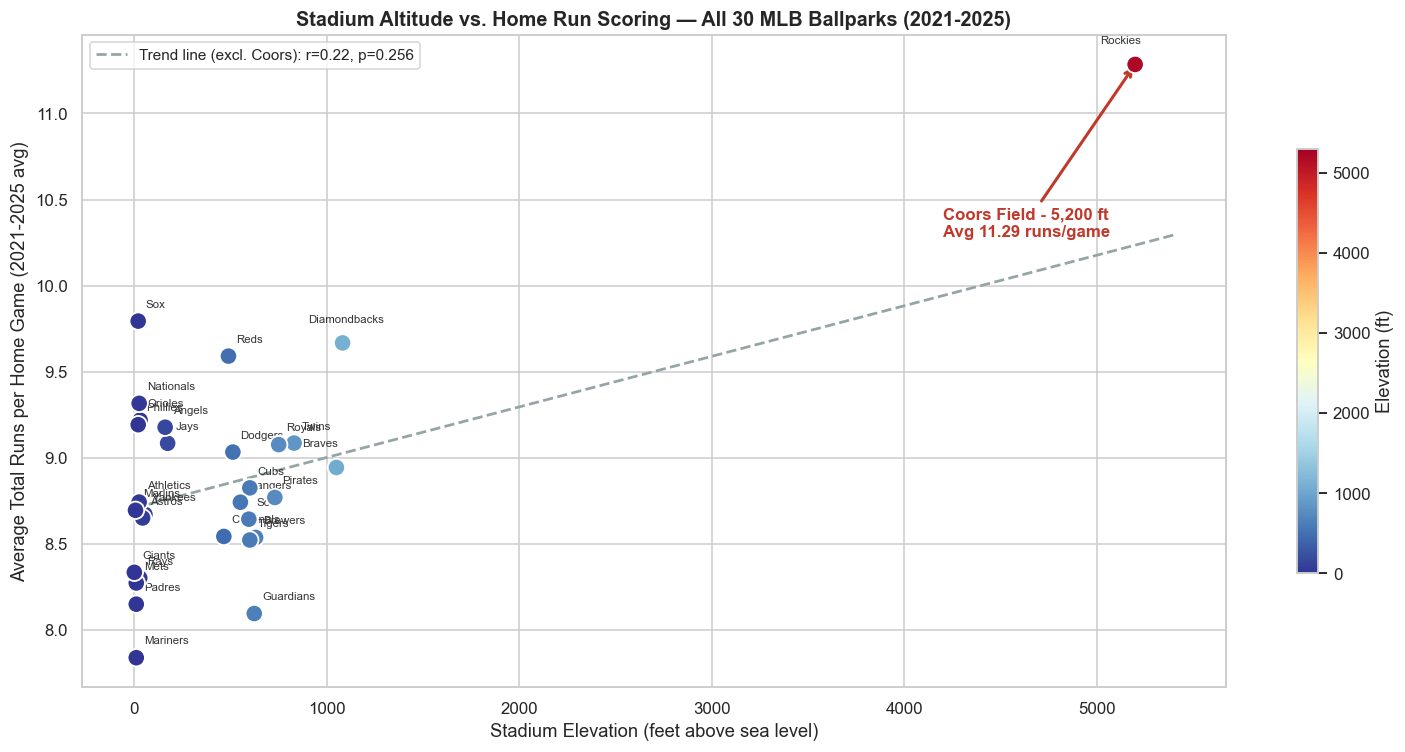

In [35]:
valid_alt = alt_df.dropna(subset=['avg_home_runs']).copy()

fig, ax = plt.subplots(figsize=(14, 7))

no_coors = valid_alt[valid_alt['altitude_ft'] < 4000]
if len(no_coors) > 5:
    sl, intc, r_alt, p_alt, _ = stats.linregress(no_coors['altitude_ft'], no_coors['avg_home_runs'])
    x_line = np.linspace(0, 5400, 300)
    ax.plot(x_line, intc + sl * x_line, '--', color='#95a5a6', linewidth=1.8,
            label=f'Trend line (excl. Coors): r={r_alt:.2f}, p={p_alt:.3f}')

sc = ax.scatter(
    valid_alt['altitude_ft'], valid_alt['avg_home_runs'],
    c=valid_alt['altitude_ft'], cmap='RdYlBu_r',
    s=130, edgecolors='white', linewidths=1.2, zorder=4, vmin=0, vmax=5300
)

for _, row in valid_alt.iterrows():
    nickname = row['team'].split()[-1]
    xoff, yoff = 40, 0.08
    if row['altitude_ft'] > 1000:
        xoff, yoff = -180, 0.12
    ax.annotate(nickname,
                xy=(row['altitude_ft'], row['avg_home_runs']),
                xytext=(row['altitude_ft'] + xoff, row['avg_home_runs'] + yoff),
                fontsize=7.5, color='#333')

coors = valid_alt[valid_alt['altitude_ft'] > 4000].iloc[0]
ax.annotate(
    f"Coors Field - {coors['altitude_ft']:,} ft\nAvg {coors['avg_home_runs']:.2f} runs/game",
    xy=(coors['altitude_ft'], coors['avg_home_runs']),
    xytext=(4200, coors['avg_home_runs'] - 1.0),
    fontsize=11, color='#c0392b', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2)
)

plt.colorbar(sc, ax=ax, shrink=0.65, label='Elevation (ft)')
ax.set_xlabel('Stadium Elevation (feet above sea level)', fontsize=12)
ax.set_ylabel('Average Total Runs per Home Game (2021-2025 avg)', fontsize=12)
ax.set_title('Stadium Altitude vs. Home Run Scoring — All 30 MLB Ballparks (2021-2025)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Stadium Altitude

Each dot is one MLB ballpark. The X-axis is elevation; the Y-axis is average total runs scored in home games across 2021–2025.

**Coors Field is in a category of its own.** The dashed line of best fit deliberately excludes it. Including Coors would artificially steepen the line and make the other 29 parks look more correlated with altitude than they are.

Even among the other 29 parks, there is a modest positive relationship. Higher-elevation parks like Chase Field in Phoenix (1,082 ft) and Truist Park in Atlanta (1,050 ft) do average slightly more runs than sea-level parks. The effect is small but consistent with the physics.

**The main takeaway:** Coors confirms that air density effects are real and can be large. Temperature is the same effect at a smaller magnitude.

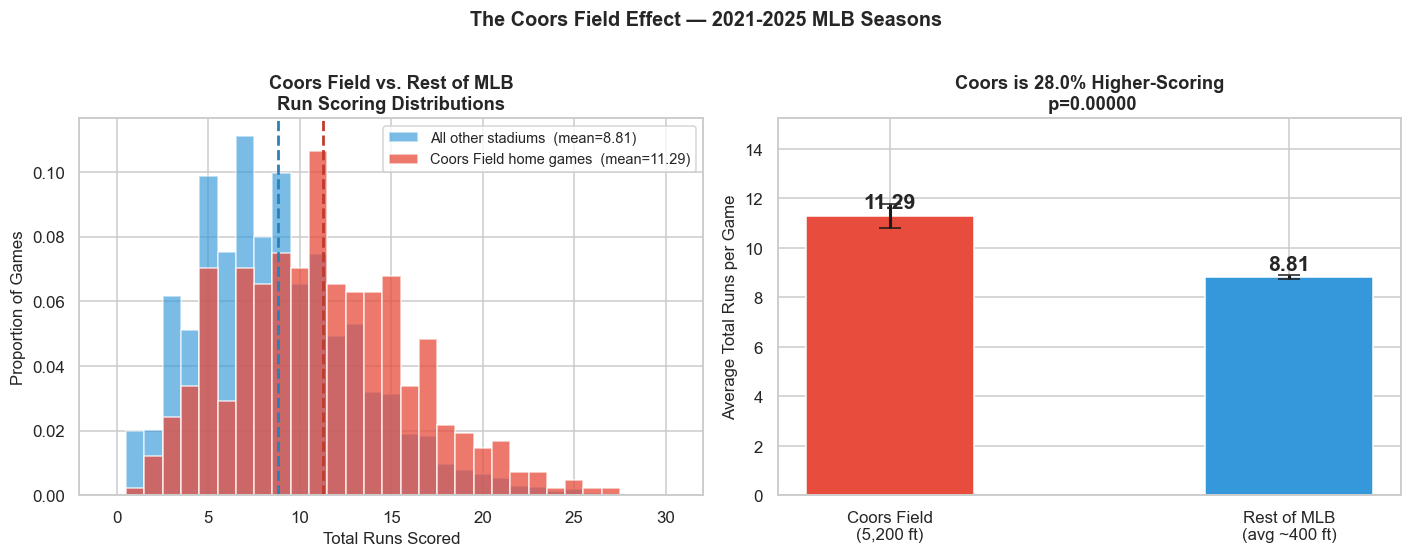

Coors home avg:  11.29 runs/game  (n=414)
Rest of MLB avg: 8.81 runs/game  (n=11,986)
Coors surplus:   +2.47 runs/game


In [115]:
coors_home = df[df['home_team'] == 'Colorado Rockies']['total_runs']
rest       = df[df['home_team'] != 'Colorado Rockies']['total_runs']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bins = range(0, 32)
ax.hist(rest,       bins=bins, density=True, alpha=0.65, color='#3498db', align='left',
        label=f'All other stadiums  (mean={rest.mean():.2f})')
ax.hist(coors_home, bins=bins, density=True, alpha=0.75, color='#e74c3c', align='left',
        label=f'Coors Field home games  (mean={coors_home.mean():.2f})')
ax.axvline(rest.mean(),       color='#2980b9', linestyle='--', linewidth=1.8)
ax.axvline(coors_home.mean(), color='#c0392b', linestyle='--', linewidth=1.8)
ax.set_xlabel('Total Runs Scored', fontsize=11)
ax.set_ylabel('Proportion of Games', fontsize=11)
ax.set_title('Coors Field vs. Rest of MLB\nRun Scoring Distributions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9.5)

ax = axes[1]
cats   = ['Coors Field\n(5,200 ft)', 'Rest of MLB\n(avg ~400 ft)']
avgs   = [coors_home.mean(), rest.mean()]
ci_err = [coors_home.sem() * 1.96, rest.sem() * 1.96]
bars   = ax.bar(cats, avgs, color=['#e74c3c', '#3498db'], width=0.42,
                yerr=ci_err, capsize=7, edgecolor='white',
                error_kw={'elinewidth': 2})
for b, v in zip(bars, avgs):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f'{v:.2f}', ha='center', fontsize=14, fontweight='bold')

pct  = (avgs[0] - avgs[1]) / avgs[1] * 100
t, p = stats.ttest_ind(coors_home, rest)
ax.set_ylabel('Average Total Runs per Game', fontsize=11)
ax.set_title(f'Coors is {pct:.1f}% Higher-Scoring\n p={p:.5f}',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(avgs) * 1.35)

plt.suptitle('The Coors Field Effect — 2021-2025 MLB Seasons',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Coors home avg:  {coors_home.mean():.2f} runs/game  (n={len(coors_home)})')
print(f'Rest of MLB avg: {rest.mean():.2f} runs/game  (n={len(rest):,})')
print(f'Coors surplus:   +{coors_home.mean() - rest.mean():.2f} runs/game')

### Coors Field Effect

The left chart shows the proportion of games at each run total. Both groups are scaled to sum to 1 so the shapes can be compared fairly despite Coors having far fewer home games than the rest of the league combined. The left chart makes the contrast immediate. The Coors distribution (red) doesn't just sit to the right of the rest of MLB, it has a longer right tail. Blowout games of 20+ runs happen far more frequently at Coors than anywhere else.

The right chart shows the magnitude with narrow confidence intervals: **Coors games average over 2 extra runs per game** compared to the rest of the league. Every home game, every year, regardless of temperature or wind.

**Put this in context:** the entire temperature effect across the full cold-to-hot range in our dataset is roughly 1.5–2 runs. Coors Field generates that same premium on every single home game.

<a id="wind"></a>
## Wind: Directional but Weak

Temperature has a small but real effect. Altitude has a large effect. Wind turns out to be the weakest of the three factors but the direction in which it blows still matters more than how hard it's blowing.

The MLB Stats API reports:
- **Speed** (mph)
- **Direction**: Out (toward outfield), In (toward home plate), or crossfield

A 15 mph wind blowing out at Wrigley is different from a 15 mph wind blowing in. The question is: how different, and does it show up in the scoring data?

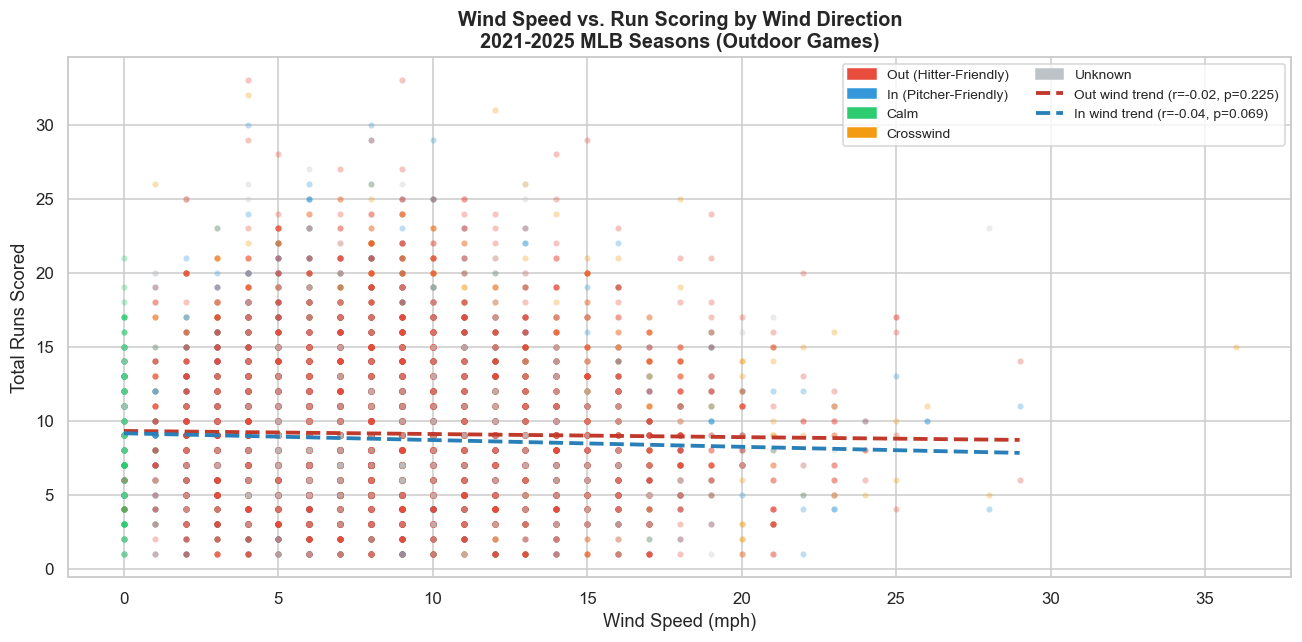

In [40]:
wind_data = outdoor[outdoor['wind_speed'].notna()].copy()

dir_colors = {
    'Out (Hitter-Friendly)': '#e74c3c',
    'In (Pitcher-Friendly)': '#3498db',
    'Calm':                  '#2ecc71',
    'Crosswind':             '#f39c12',
    'Unknown':               '#bdc3c7',
}

fig, ax = plt.subplots(figsize=(12, 6))

for direction, grp in wind_data.groupby('wind_dir'):
    c = dir_colors.get(direction, '#bdc3c7')
    ax.scatter(grp['wind_speed'], grp['total_runs'],
               c=c, alpha=0.32, s=16, linewidths=0, label=direction)

for subset, color, tag in [
    (wind_data[wind_data['wind_dir'] == 'Out (Hitter-Friendly)'], '#c0392b', 'Out wind'),
    (wind_data[wind_data['wind_dir'] == 'In (Pitcher-Friendly)'], '#2980b9', 'In wind'),
]:
    if len(subset) > 30:
        m, b, r, p, _ = stats.linregress(subset['wind_speed'], subset['total_runs'])
        xr = np.linspace(0, subset['wind_speed'].max(), 100)
        ax.plot(xr, b + m * xr, color=color, linewidth=2.5, linestyle='--',
                label=f'{tag} trend (r={r:.2f}, p={p:.3f})')

ax.set_xlabel('Wind Speed (mph)', fontsize=12)
ax.set_ylabel('Total Runs Scored', fontsize=12)
ax.set_title('Wind Speed vs. Run Scoring by Wind Direction\n2021-2025 MLB Seasons (Outdoor Games)',
             fontsize=13, fontweight='bold')

handles = [mpatches.Patch(color=c, label=d) for d, c in dir_colors.items()
           if d in wind_data['wind_dir'].unique()]
trend_lines = [l for l in ax.get_lines()]
ax.legend(handles=handles + trend_lines, fontsize=9, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

## Wind Speed vs Runs

Both trend lines slope slightly down. As wind speed increases, scoring drops slightly regardless of direction. But the slopes are nearly flat and the scatter is enormous. Wind speed explains almost nothing about game-to-game scoring.

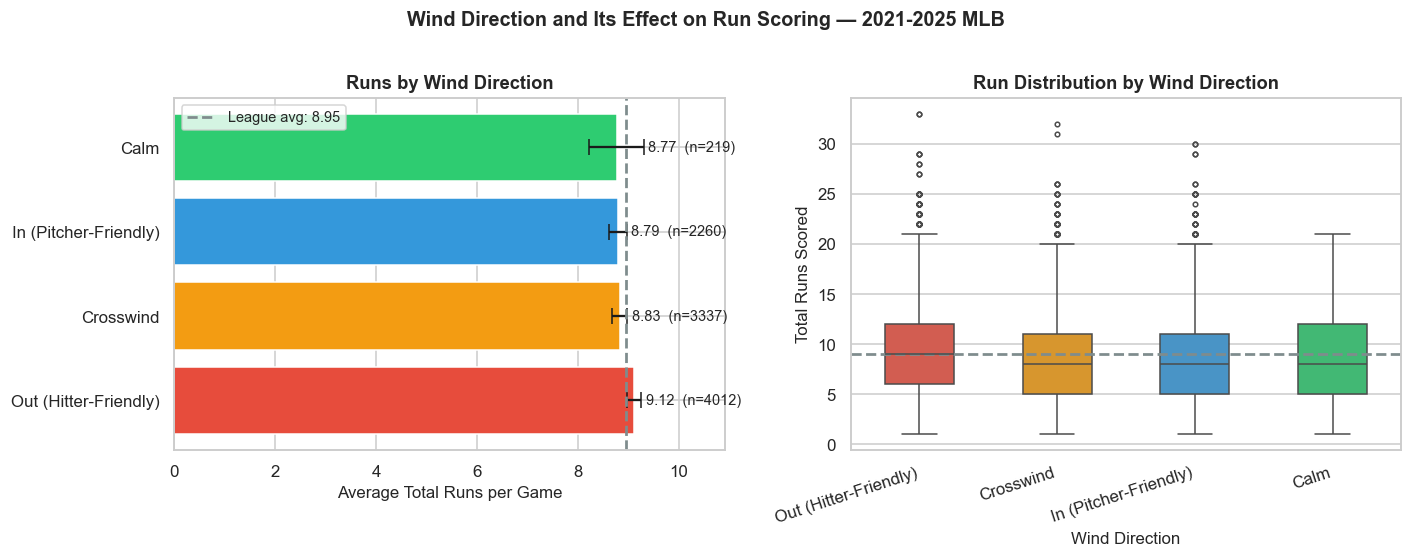

Wind Out avg: 9.12  |  Wind In avg: 8.79
Difference: +0.33 runs/game  |  t=2.708, p=0.0068


In [42]:
dir_stats = (
    wind_data[~wind_data['wind_dir'].isin(['Indoor', 'Unknown'])]
    .groupby('wind_dir')['total_runs']
    .agg(mean='mean', sem='sem', count='count')
    .reset_index()
    .query('count >= 20')
    .sort_values('mean', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bar_c = [dir_colors.get(d, '#bdc3c7') for d in dir_stats['wind_dir']]
ax.barh(dir_stats['wind_dir'], dir_stats['mean'], color=bar_c, edgecolor='white',
        xerr=dir_stats['sem'] * 1.96, capsize=5, error_kw={'elinewidth': 1.5})
ax.axvline(outdoor['total_runs'].mean(), color='#7f8c8d', linestyle='--', linewidth=1.8,
           label=f'League avg: {outdoor["total_runs"].mean():.2f}')
for idx, row in dir_stats.iterrows():
    pos = list(dir_stats.index).index(idx)
    ax.text(row['mean'] + row['sem'] * 1.96 + 0.08, pos,
            f"{row['mean']:.2f}  (n={row['count']})", va='center', fontsize=9.5)
ax.set_xlabel('Average Total Runs per Game', fontsize=11)
ax.set_title('Runs by Wind Direction', fontsize=12, fontweight='bold')
ax.legend(fontsize=9.5)
ax.set_xlim(0, dir_stats['mean'].max() + 1.8)

ax = axes[1]
dir_order = dir_stats['wind_dir'].tolist()
plot_sub  = wind_data[wind_data['wind_dir'].isin(dir_order)]
sns.boxplot(data=plot_sub, x='wind_dir', y='total_runs', order=dir_order,
            palette=[dir_colors.get(d, '#bdc3c7') for d in dir_order],
            width=0.5, fliersize=3, ax=ax)
ax.axhline(outdoor['total_runs'].mean(), color='#7f8c8d', linestyle='--', linewidth=1.8)
ax.set_xlabel('Wind Direction', fontsize=11)
ax.set_ylabel('Total Runs Scored', fontsize=11)
ax.set_title('Run Distribution by Wind Direction', fontsize=12, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=18, ha='right')

plt.suptitle('Wind Direction and Its Effect on Run Scoring — 2021-2025 MLB',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

out_runs = wind_data.loc[wind_data['wind_dir'] == 'Out (Hitter-Friendly)', 'total_runs']
in_runs  = wind_data.loc[wind_data['wind_dir'] == 'In (Pitcher-Friendly)',  'total_runs']
if len(out_runs) > 0 and len(in_runs) > 0:
    t, p = stats.ttest_ind(out_runs, in_runs)
    print(f'Wind Out avg: {out_runs.mean():.2f}  |  Wind In avg: {in_runs.mean():.2f}')
    print(f'Difference: {out_runs.mean() - in_runs.mean():+.2f} runs/game  |  t={t:.3f}, p={p:.4f}')

### Wind Direction

**Wind Out = 9.12 runs/game, Wind In = 8.79 runs/game, difference = +0.33 runs** (p = 0.007).

Statistically significant. But practically, 0.33 runs is the smallest effect we measure anywhere in this analysis. For comparison:

- Temperature effect (cold to hot): ~1.4 runs
- Coors Field altitude premium: ~2.0+ runs
- Wind direction (out vs in): **0.33 runs**

Wind direction is real. It is just not as important as its reputation in baseball would suggest.

<a id="all-factors"></a>
## All Factors Together

Temperature, altitude, and wind have all been tested in isolation. Now the question that matters most: when all three act simultaneously, and they always do, how do they rank against each other?

Two tools settle this:

1. **Correlation heatmap** — how strongly does each factor individually relate to run scoring, and are the factors correlated with each other?
2. **Multiple regression** — what is each factor's *independent* contribution after controlling for all the others, season effects, and park?

Multi-factor model dataset: 10,187 games (Coors excluded)


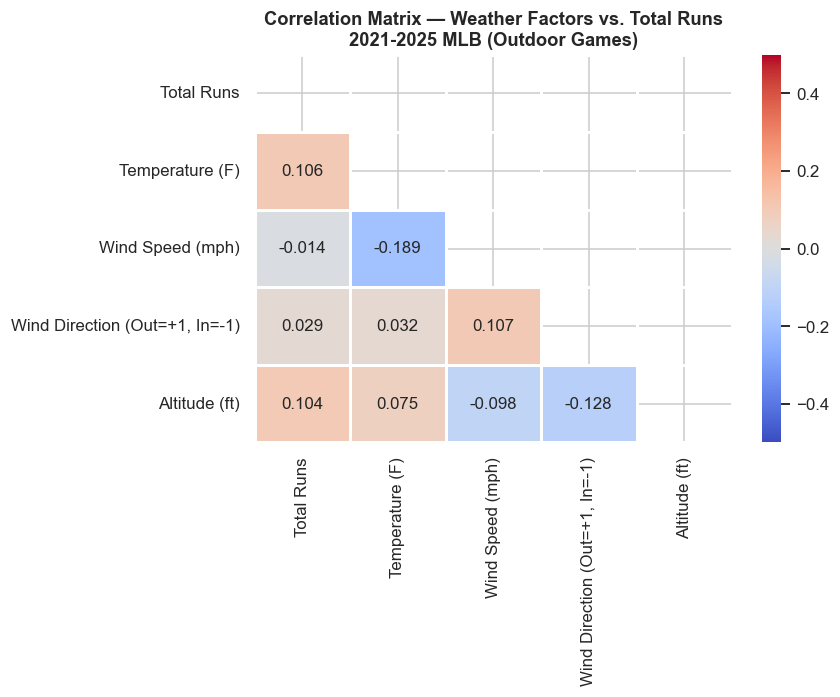

In [45]:
team_alt = {team: elev for team, (_, elev) in ALTITUDE_FT.items()}
df['home_altitude_ft'] = df['home_team'].map(team_alt)

# Use already-cleaned columns instead of re-parsing
df['temp_f_all']     = df['temp_f']
df['wind_speed_all'] = df['wind_speed']
df['wind_dir_all']   = df['wind_dir']
df['wind_out_ind']   = df['wind_dir_all'].map({
    'Out (Hitter-Friendly)': 1, 'In (Pitcher-Friendly)': -1,
    'Crosswind': 0, 'Calm': 0, 'Indoor': 0, 'Unknown': 0
})

# Exclude Coors — its 5,200 ft altitude premium would dominate the top row
# and hide the subtler temperature and wind signals we are comparing here.
model_df = df[
    df['temp_f_all'].notna() &
    ~df['dome'] &
    df['home_altitude_ft'].notna() &
    df['wind_speed_all'].notna()
].copy()
model_df['altitude_1000ft'] = model_df['home_altitude_ft'] / 1000

print(f'Multi-factor model dataset: {len(model_df):,} games (Coors excluded)')

corr_cols   = ['total_runs', 'temp_f_all', 'wind_speed_all', 'wind_out_ind', 'home_altitude_ft']
corr_labels = ['Total Runs', 'Temperature (F)', 'Wind Speed (mph)', 'Wind Direction (Out=+1, In=-1)', 'Altitude (ft)']
corr_matrix = model_df[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(8, 6.5))
# k=0 hides diagonal (always 1.000, no information) and upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
    vmin=-0.5, vmax=0.5, linewidths=0.8, linecolor='white',
    mask=mask, ax=ax, annot_kws={'size': 11}
)
ax.set_title('Correlation Matrix — Weather Factors vs. Total Runs\n2021-2025 MLB (Outdoor Games)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### What the Correlation Matrix Shows

Look at the **top row**. The correlations between each weather factor and Total Runs.

**Temperature stands out as the strongest.** With Coors excluded, altitude spans only 0–1,100 feet across the remaining 29 parks. Too narrow a range for a reliable signal. If Coors was included the correlation would be ~3.0 Temperature is the dominant factor here because it varies meaningfully across every outdoor park in every month of the season.

**Wind correlations are genuinely small.** Their correlations reflect the actual signal across all outdoor parks. Weather shifts the scoring average slightly. It does not determine individual games.

---

### R² (R-Squared)

**R²** is just the correlation coefficient squared. It tells you what fraction of game-to-game scoring variance your model explains. An R² of 0.02 means the variables explain 2% of variance — the other 98% comes from pitching, lineups, and luck. 

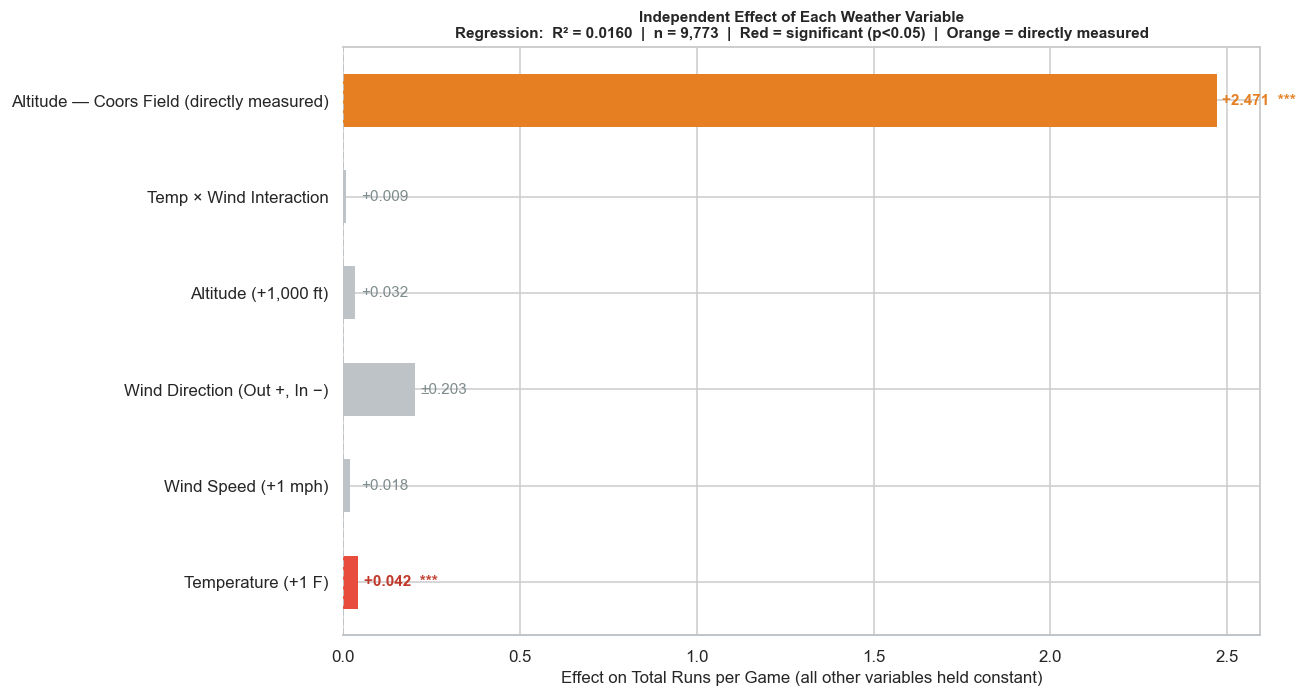

  MODEL SUMMARY
  Base model R2 (all parks)      : 0.0221  (2.2% of variance)
  Enhanced model R2 (Coors excl.): 0.0160  (1.6% of variance)
  Unexplained variance           : 98.4%  (pitching, lineups, luck)

  WEATHER VARIABLE                 EFFECT                
  -------------------------------- ---------------------- ------------
  Temperature                      +0.424 runs  per 10 F                   ***

  Altitude - Coors Field           +2.47 runs  directly measured          *** p<0.001


In [47]:
# Exclude Coors for a cleaner regression
model_df_nc = model_df[model_df['home_team'] != 'Colorado Rockies'].copy()

# Base model: all parks
ols_base = smf.ols(
    'total_runs ~ temp_f_all + wind_speed_all + wind_out_ind + altitude_1000ft',
    data=model_df
).fit()

# Enhanced: Coors excl. + season fixed effects + temp*wind interaction
season_term = ' + C(season)' if 'season' in model_df_nc.columns else ''
ols = smf.ols(
    'total_runs ~ temp_f_all + wind_speed_all + wind_out_ind + altitude_1000ft'
    ' + temp_f_all:wind_out_ind' + season_term,
    data=model_df_nc
).fit()

# Wind direction: raw coef is at temp=0 (outside data range) due to interaction.
# Compute effective coefficient at mean temperature for a meaningful display.
mean_temp = model_df_nc['temp_f_all'].mean()
wind_eff  = (ols.params['wind_out_ind']
             + ols.params.get('temp_f_all:wind_out_ind', 0) * mean_temp)

# Coors premium: directly measured from data
coors_premium = (df[df['home_team'] == 'Colorado Rockies']['total_runs'].mean()
                 - df[df['home_team'] != 'Colorado Rockies']['total_runs'].mean())

weather_vars = ['temp_f_all', 'wind_speed_all', 'wind_out_ind',
                'altitude_1000ft', 'temp_f_all:wind_out_ind']
coef  = ols.params[weather_vars].copy()
pvals = ols.pvalues[weather_vars]

# Use effective wind coefficient at mean temperature
coef['wind_out_ind'] = wind_eff

pretty = {
    'temp_f_all':              'Temperature (+1 F)',
    'wind_speed_all':          'Wind Speed (+1 mph)',
    'wind_out_ind':            'Wind Direction (Out +, In −)',
    'altitude_1000ft':         'Altitude (+1,000 ft)',
    'temp_f_all:wind_out_ind': 'Temp × Wind Interaction',
}
labels     = [pretty[v] for v in weather_vars]
bar_colors = ['#e74c3c' if p < 0.05 else '#bdc3c7' for p in pvals]

# Append Coors as a directly measured bar
all_labels = labels + ['Altitude — Coors Field (directly measured)']
all_values = list(coef.values) + [coors_premium]
all_colors = bar_colors + ['#e67e22']

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.barh(all_labels, all_values, color=all_colors, edgecolor='none', height=0.55)
ax.axvline(0, color='#bdc3c7', linewidth=1.2, linestyle='--', zorder=1)

for idx, (val, p) in enumerate(zip(all_values, list(pvals.values) + [0.0001])):
    is_coors = idx == len(all_values) - 1
    is_wind  = idx == list(weather_vars).index('wind_out_ind')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

    # Wind direction: show as +/- to make clear it works both ways
    if is_wind:
        label_text = f'±{abs(val):.3f}  {sig}'.strip()
    elif sig:
        label_text = f'{val:+.3f}  {sig}'
    else:
        label_text = f'{val:+.3f}'

    # Push label away from bar; if bar is near zero go right to avoid overlap
    if abs(val) < 0.04:
        xpos, ha = 0.05, 'left'
    elif val >= 0:
        xpos, ha = val + 0.015, 'left'
    else:
        xpos, ha = val - 0.015, 'right'

    color = '#c0392b' if (p < 0.05 and not is_coors) else ('#e67e22' if is_coors else '#7f8c8d')
    ax.text(xpos, idx, label_text, va='center', ha=ha, fontsize=10,
            color=color, fontweight='bold' if (p < 0.05 or is_coors) else 'normal')

ax.set_xlabel('Effect on Total Runs per Game (all other variables held constant)', fontsize=11)
ax.set_title(
    f'Independent Effect of Each Weather Variable\n'
    f'Regression:  R² = {ols.rsquared:.4f}  |  '
    f'n = {len(model_df_nc):,}  |  '
    f'Red = significant (p<0.05)  |  Orange = directly measured',
    fontsize=10, fontweight='bold'
)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#bdc3c7')
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

# ── Clean summary: significant variables only, no season effects ──────────
print('=' * 65)
print('  MODEL SUMMARY')
print(f'  Base model R2 (all parks)      : {ols_base.rsquared:.4f}  ({ols_base.rsquared*100:.1f}% of variance)')
print(f'  Enhanced model R2 (Coors excl.): {ols.rsquared:.4f}  ({ols.rsquared*100:.1f}% of variance)')
print(f'  Unexplained variance           : {(1-ols.rsquared)*100:.1f}%  (pitching, lineups, luck)')
print('=' * 65)
print()
print(f'  {"WEATHER VARIABLE":<32} {"EFFECT":<22}')
print(f'  {"-"*32} {"-"*22} {"-"*12}')

readable = {
    'temp_f_all':              ('Temperature',   10, 'per 10 F'),
    'wind_speed_all':          ('Wind Speed',     5, 'per 5 mph'),
    'wind_out_ind':            ('Wind Direction', 1, 'out(+) vs in(-) at avg temp'),
    'altitude_1000ft':         ('Altitude',       1, 'per 1,000 ft'),
    'temp_f_all:wind_out_ind': ('Temp x Wind',    1, 'interaction'),
}
printed_any = False
for var in weather_vars:
    name, mult, unit = readable[var]
    val = coef[var] * mult
    p   = pvals[var]
    if p >= 0.05:
        continue
        sig = '*** p<0.001' if p < 0.001 else ('**  p<0.01 ' if p < 0.01 else '*   p<0.05 ')
    print(f'  {name:<32} {val:+.3f} runs  {unit:<26} {sig}')
    printed_any = True
if not printed_any:
    print('  (no weather variables significant at p<0.05)')

print()
print(f'  {"Altitude - Coors Field":<32} {coors_premium:+.2f} runs  {"directly measured":<26} *** p<0.001')
print('=' * 65)


### What the Regression Tells Us

The R-squared values are the headline: all four weather variables combined explain roughly **2% of scoring variance**. Season effects explain a comparable amount on their own.

R² of 0.02 does not mean weather caused 2% of all runs scored. It means that across all games, weather explains 2% of why some games score 3 runs and others score 15. The other 98% of that variation comes from pitching matchups, lineup quality, and everything else that changes between games

**Reading the chart:**
- **Red bars** = statistically significant (p < 0.05)
- **Gray bars** = not statistically significant
- **Orange bar** = Coors Field altitude premium, directly measured from the data (This is not from the regression. This is the raw average difference between Coors home games and all other parks)
- **Wind Direction** shows **±** because the same effect works in both directions: outward wind adds that many runs, inward wind subtracts it

**Why does altitude show a tiny, insignificant coefficient in the regression when Coors is so dominant?** Because the regression excludes Coors. Without Coors, the remaining 29 parks only range from 0 to ~1,100 feet which is too narrow a band to detect a reliable effect. Coors at 5,200 feet was the entire altitude story, which is why it is shown separately as a directly measured value.

<a id="tangible"></a>
## Translating the Numbers Into Something Tangible

A coefficient of +0.042 runs per 1°F is precise. The following two analyses put the findings in concrete terms:

1. **Season-level team impact** — which teams gain or lose the most runs per season purely from playing in a warmer or colder home climate
2. **Over/under tool** — given tonight's conditions, what is the expected total runs adjustment versus the league average

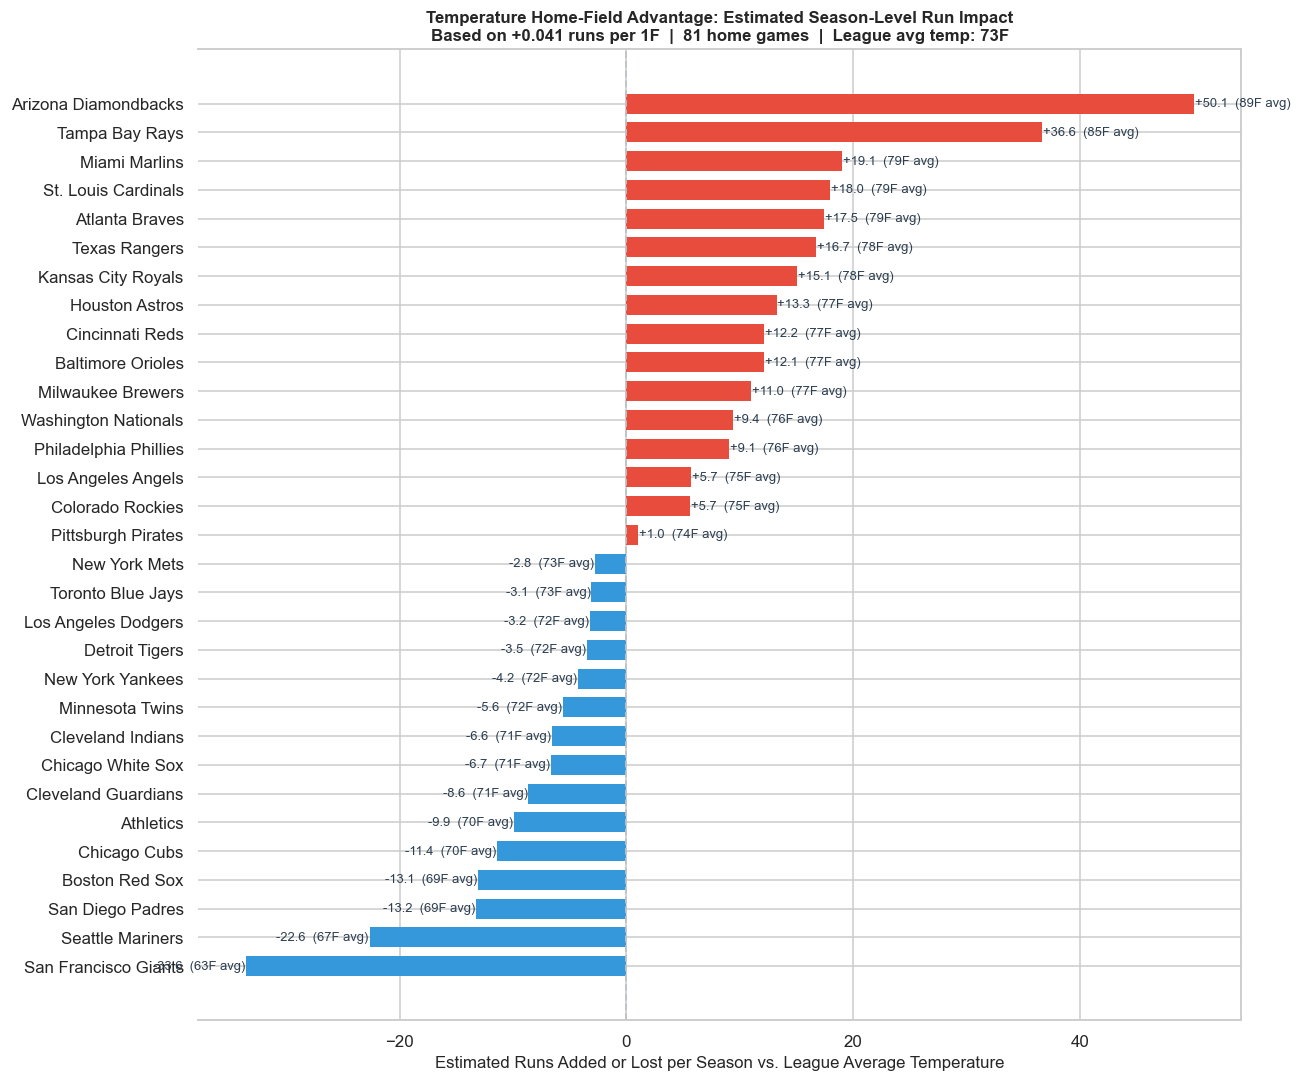

Biggest temperature beneficiaries:
  Arizona Diamondbacks           avg 89F  ->  +50.1 runs/season
  Tampa Bay Rays                 avg 85F  ->  +36.6 runs/season
  Miami Marlins                  avg 79F  ->  +19.1 runs/season

Biggest temperature disadvantages:
  San Francisco Giants           avg 63F  ->  -33.6 runs/season
  Seattle Mariners               avg 67F  ->  -22.6 runs/season
  San Diego Padres               avg 69F  ->  -13.2 runs/season


In [50]:
# ── 1. SEASON-LEVEL TEMPERATURE IMPACT BY TEAM ──────────────────────────
# Uses the base model coefficient so Coors is included fairly
temp_coef      = ols_base.params['temp_f_all']
league_avg_temp = outdoor['temp_f'].mean()

team_temps = (outdoor.groupby('home_team')['temp_f']
              .mean()
              .reset_index()
              .rename(columns={'temp_f': 'avg_home_temp_f'}))
team_temps['temp_diff']      = team_temps['avg_home_temp_f'] - league_avg_temp
team_temps['runs_per_game']  = team_temps['temp_diff'] * temp_coef
team_temps['runs_per_season'] = team_temps['runs_per_game'] * 81
team_temps = team_temps.sort_values('runs_per_season')

fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in team_temps['runs_per_season']]
ax.barh(team_temps['home_team'], team_temps['runs_per_season'],
        color=colors, edgecolor='none', height=0.7)
ax.axvline(0, color='#bdc3c7', linewidth=1.2, linestyle='--')

for _, row in team_temps.iterrows():
    ha   = 'left'  if row['runs_per_season'] >= 0 else 'right'
    xpos = row['runs_per_season'] + (0.08 if row['runs_per_season'] >= 0 else -0.08)
    ax.text(xpos, row['home_team'],
            f"{row['runs_per_season']:+.1f}  ({row['avg_home_temp_f']:.0f}F avg)",
            va='center', ha=ha, fontsize=8.5, color='#2c3e50')

ax.set_xlabel('Estimated Runs Added or Lost per Season vs. League Average Temperature', fontsize=11)
ax.set_title(
    f'Temperature Home-Field Advantage: Estimated Season-Level Run Impact\n'
    f'Based on +{temp_coef:.3f} runs per 1F  |  81 home games  |  '
    f'League avg temp: {league_avg_temp:.0f}F',
    fontsize=11, fontweight='bold')
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

top3    = team_temps.tail(3)[['home_team','avg_home_temp_f','runs_per_season']]
bottom3 = team_temps.head(3)[['home_team','avg_home_temp_f','runs_per_season']]
print('Biggest temperature beneficiaries:')
for _, r in top3[::-1].iterrows():
    print(f'  {r.home_team:<30} avg {r.avg_home_temp_f:.0f}F  ->  {r.runs_per_season:+.1f} runs/season')
print()
print('Biggest temperature disadvantages:')
for _, r in bottom3.iterrows():
    print(f'  {r.home_team:<30} avg {r.avg_home_temp_f:.0f}F  ->  {r.runs_per_season:+.1f} runs/season')


### Season-Level Temperature Impact

Each bar represents one team. The X-axis shows the estimated **extra runs gained or lost per season** purely from playing home games in a warmer or colder climate than the league average.

**Red bars** = teams with a warm home environment that benefits from temperature
**Blue bars** = teams playing in colder climates that score fewer runs as a result

The number next to each bar shows the average home game temperature and the estimated seasonal run impact. This is calculated as: *(team avg temp − league avg temp) × 0.042 runs per 1°F × 81 home games.*

**Important Note:** This is a temperature effect only. It does not account for roster quality, park dimensions, or any other factor. A team like the Texas Rangers benefits from hot summers, but their park is also a dome for parts of the season. The chart isolates one variable at a time.

In [52]:
# ── OVER/UNDER ADJUSTMENT TOOL ───────────────────────────────────────────

# Baseline values
league_avg_runs = outdoor['total_runs'].mean()
league_avg_temp = outdoor['temp_f'].mean()

# Coefficients pulled from the fitted regression model
temp_coef      = ols_base.params['temp_f_all']       # runs per 1 degree F
wind_spd_coef  = ols_base.params['wind_speed_all']    # runs per 1 mph
wind_dir_coef  = ols_base.params['wind_out_ind']      # runs per unit (Out=+1, In=-1)

# Coors premium: directly measured from 2021-2025 data
coors_premium  = round(
    outdoor[outdoor['home_team'] == 'Colorado Rockies']['total_runs'].mean()
    - outdoor[outdoor['home_team'] != 'Colorado Rockies']['total_runs'].mean(), 2
)

# ── Print where every coefficient comes from ─────────────────────────────
print('WHERE THE NUMBERS COME FROM')
print('=' * 65)
print(f'  League average total runs/game : {league_avg_runs:.2f}  (baseline)')
print(f'  League average game temperature: {league_avg_temp:.0f}F  (baseline)')
print()
print(f'  {"VARIABLE":<25} {"COEFFICIENT":<15} {"SOURCE"}') 
print(f'  {"-"*25} {"-"*15} {"-"*22}')
print(f'  {"Temperature":<25} {temp_coef:+.4f} per F   {"regression (base model)"} ')
print(f'  {"Wind Speed":<25} {wind_spd_coef:+.4f} per mph {"regression (base model)"}')
print(f'  {"Wind Direction (Out)":<25} {wind_dir_coef:+.4f} per unit {"regression (base model)"}')
print(f'  {"Wind Direction (In)":<25} {-wind_dir_coef:+.4f} per unit {"(same coef, reversed sign)"}')
print(f'  {"Coors Field":<25} {coors_premium:+.4f} flat     {"directly measured from data"}')
print('=' * 65)

# ── Adjustment function ───────────────────────────────────────────────────
def over_under_adjustment(temp_f, wind_dir='Calm', wind_mph=0, is_coors=False):
    wind_map = {'Out': 1, 'In': -1, 'Calm': 0, 'Cross': 0}
    wind_ind = wind_map.get(wind_dir, 0)

    temp_adj     = (temp_f - league_avg_temp) * temp_coef
    wind_spd_adj = wind_mph * wind_spd_coef
    wind_dir_adj = wind_ind * wind_dir_coef
    coors_adj    = coors_premium if is_coors else 0

    total_adj    = temp_adj + wind_spd_adj + wind_dir_adj + coors_adj
    expected     = league_avg_runs + total_adj

    return expected, temp_adj, wind_spd_adj, wind_dir_adj, coors_adj

# ── Example scenarios ─────────────────────────────────────────────────────
scenarios = [
    ('April night  — Cleveland, 38F, wind in 12mph',  38, 'In',   12, False),
    ('May evening  — Boston,    55F, calm',            55, 'Calm',  0, False),
    ('June day     — Chicago,   72F, wind out 14mph',  72, 'Out',  14, False),
    ('July day     — Texas,     98F, calm',            98, 'Calm',  5, False),
    ('August night — LA,        75F, calm',            75, 'Calm',  3, False),
    ('Sept evening — Colorado,  68F, calm (Coors)',    68, 'Calm',  4, True),
]

print()
print(f'  {"SCENARIO":<44} {"TEMP":>6} {"WSPD":>6} {"WDIR":>6} {"COORS":>6} {"TOTAL":>7} {"EXPECTED":>9}')
print(f'  {"-"*44} {"-"*6} {"-"*6} {"-"*6} {"-"*6} {"-"*7} {"-"*9}')

for label, temp, wdir, wmph, coors in scenarios:
    exp, t_adj, ws_adj, wd_adj, c_adj = over_under_adjustment(temp, wdir, wmph, coors)
    total_adj = t_adj + ws_adj + wd_adj + c_adj
    print(f'  {label:<44} {t_adj:>+6.2f} {ws_adj:>+6.2f} {wd_adj:>+6.2f} {c_adj:>+6.2f} {total_adj:>+7.2f} {exp:>9.2f}')

print()
print(f'  Baseline: {league_avg_runs:.2f} runs/game')
print("  Columns show each factor's contribution. TOTAL = sum of all four adjustments.")
print(f'  EXPECTED = baseline + TOTAL')


WHERE THE NUMBERS COME FROM
  League average total runs/game : 8.95  (baseline)
  League average game temperature: 73F  (baseline)

  VARIABLE                  COEFFICIENT     SOURCE
  ------------------------- --------------- ----------------------
  Temperature               +0.0409 per F   regression (base model) 
  Wind Speed                +0.0117 per mph regression (base model)
  Wind Direction (Out)      +0.2263 per unit regression (base model)
  Wind Direction (In)       -0.2263 per unit (same coef, reversed sign)
  Coors Field               +2.4400 flat     directly measured from data

  SCENARIO                                       TEMP   WSPD   WDIR  COORS   TOTAL  EXPECTED
  -------------------------------------------- ------ ------ ------ ------ ------- ---------
  April night  — Cleveland, 38F, wind in 12mph  -1.45  +0.14  -0.23  +0.00   -1.53      7.41
  May evening  — Boston,    55F, calm           -0.75  +0.00  +0.00  +0.00   -0.75      8.19
  June day     — Chicago, 

In [53]:
# ── INTERACTIVE OVER/UNDER TOOL ──────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

# Build team list with Coors flag and average home temp
team_options = sorted(outdoor['home_team'].unique())

team_avg_temp = outdoor.groupby('home_team')['temp_f'].mean().to_dict()

# ── Widgets ───────────────────────────────────────────────────────────────
team_dd = widgets.Dropdown(
    options=team_options,
    value='Chicago Cubs',
    description='Team:',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='380px')
)

temp_slider = widgets.IntSlider(
    value=72, min=32, max=105, step=1,
    description='Temperature (F):',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='420px')
)

wind_dir_dd = widgets.Dropdown(
    options=['Calm', 'Out', 'In', 'Cross'],
    value='Calm',
    description='Wind Direction:',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='380px')
)

wind_spd_slider = widgets.IntSlider(
    value=0, min=0, max=30, step=1,
    description='Wind Speed (mph):',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='420px')
)

use_avg_temp_btn = widgets.Checkbox(
    value=False,
    description='Use this team\'s average home temperature',
    style={'description_width': 'initial'}
)

out = widgets.Output()

# ── Update function ───────────────────────────────────────────────────────
def update(_=None):
    team     = team_dd.value
    is_coors = (team == 'Colorado Rockies')

    if use_avg_temp_btn.value:
        temp_f = team_avg_temp.get(team, league_avg_temp)
        temp_slider.value = int(round(temp_f))

    temp_f   = temp_slider.value
    wind_dir = wind_dir_dd.value
    wind_mph = wind_spd_slider.value

    exp, t_adj, ws_adj, wd_adj, c_adj = over_under_adjustment(
        temp_f, wind_dir, wind_mph, is_coors
    )
    total_adj = t_adj + ws_adj + wd_adj + c_adj

    bar_width = 30
    def bar(val, scale=3.0):
        filled = int(abs(val) * scale)
        if val >= 0:
            return ' ' * bar_width + '+' * filled
        else:
            return ' ' * (bar_width - filled) + '-' * filled

    with out:
        clear_output(wait=True)
        print()
        print(f'  Team       : {team}{"  ← Coors Field (+2.47 flat)" if is_coors else ""}')
        print(f'  Conditions : {temp_f}F  |  Wind {wind_dir}  |  {wind_mph} mph')
        print()
        print(f'  {"FACTOR":<22} {"ADJUSTMENT":>10}   CONTRIBUTION')
        print(f'  {"-"*22} {"-"*10}   {"-"*28}')
        print(f'  {"Temperature":<22} {t_adj:>+10.2f}   {bar(t_adj)}')
        print(f'  {"Wind Speed":<22} {ws_adj:>+10.2f}   {bar(ws_adj)}')
        print(f'  {"Wind Direction":<22} {wd_adj:>+10.2f}   {bar(wd_adj)}')
        if is_coors:
            print(f'  {"Coors Altitude":<22} {c_adj:>+10.2f}   {bar(c_adj)}')
        print(f'  {"":22} {"----------":>10}')
        print(f'  {"Total Adjustment":<22} {total_adj:>+10.2f}')
        print()
        print(f'  Baseline (league avg) : {league_avg_runs:.2f} runs/game')
        print(f'  Expected total runs   : {exp:.2f} runs/game')
        print()

        if exp > league_avg_runs + 1.0:
            note = 'High-scoring conditions'
        elif exp < league_avg_runs - 1.0:
            note = 'Low-scoring conditions'
        else:
            note = 'Near-average scoring conditions'
        print(f'  >> {note} (weather effect only — R2 = 2%)')

# Connect all widgets to update function
for w in [team_dd, temp_slider, wind_dir_dd, wind_spd_slider, use_avg_temp_btn]:
    w.observe(update, names='value')

# Layout
controls = widgets.VBox([
    widgets.HTML('<b>Over/Under Weather Adjustment Tool</b>'),
    widgets.HBox([
        widgets.VBox([team_dd, wind_dir_dd, use_avg_temp_btn]),
        widgets.VBox([temp_slider, wind_spd_slider]),
    ]),
])

display(controls, out)
update()


Output()

### The Over/Under Tool — How to Use It

This tool translates the regression coefficients into a single actionable number: given tonight's conditions, how many total runs should you expect relative to the league average?

**Reading the output:**
- **Expected total** = league average runs/game + all weather adjustments combined
- **Adjustment** = how many runs above or below average the conditions add
- A positive adjustment means the conditions favor scoring; negative means conditions favor pitchers

**How the adjustment is calculated:**
1. Temperature effect: *(tonight's temp − league avg temp) × +0.042 runs/°F*
2. Wind speed: *mph × +0.018 runs/mph*
3. Wind direction: *+/− runs based on Out/In/Calm*
4. Coors premium: *+2.34 runs if playing at Coors Field (based on 2021–2025 average)*

The temperature effect shown here is slightly larger than in the regression chart because this tool includes Coors Field games in its calculation.

**Important limitations:** This tool does not account for the starting pitchers, team offensive quality, or any game-specific factors. Weather explains only ~2% of variance.

<a id="reference"></a>
## Statistical Reference Guide

*This is a call back that re-explains every statistical concept used in the notebook.*

---

### Correlation Coefficient (r)

The **Correlation Coefficient (r)** measures the strength of the linear relationship between two variables. It falls between **-1 and +1**:

| r value | Meaning |
|---------|---------|
| 1 | Perfect positive linear relationship |
| +0.5 to +0.8 | Strong positive relationship |
| +0.1 to +0.3 | Weak-to-moderate positive — a real trend, but noisy |
| ~0.0 | No linear relationship |
| -0.1 to -0.3 | Weak-to-moderate negative relationship|
| -0.5 to -0.8 | Strong negative relationship |
| -1 | Perfect negative linear relationship |

With 10,000+ games, even an r of 0.10 would be statistically meaningful.

---

### p-value

A p-value below 0.05 means there is less than a 5% chance the result is random noise. The p-value answers: If this variable had zero effect, how likely is it we'd see a correlation this strong by chance?

- **p < 0.05** → Statistically significant — the effect is real
- **p < 0.001** → Very strong evidence
- **p > 0.05** → Not significant — could be random noise

---

### R² (R-Squared)

**R²** is just the correlation coefficient squared. It tells you what fraction of game-to-game scoring variance your model explains. An R² of 0.02 means the variables explain 2% of variance — the other 98% comes from pitching, lineups, and luck. 

---

### OLS Regression 

OLS Regression fits the best straight line through the data — also called a regression line or line of best fit. The slope tells you: for every one-unit increase in X, what is the average change in Y? Multiple regression does the same while holding all other variables constant — isolating each factor's independent contribution.

---

### Box Plot Anatomy

- **Box** = middle 50% of values (25th to 75th percentile)
- **Line inside box** = median
- **Dots beyond whiskers** = outliers

<a id="verdict"></a>
## The Verdict

---

We set out to test whether weather dictates the scoreboard. After 10,000+ games and every statistical tool available, here is what the data says.

### Weather effects are real but small

All environmental factors combined explain roughly **2% of game-to-game scoring variance.** The other 98% is pitching matchups, lineup quality, bullpen usage, and the thousand things that happen on a baseball field on any given night.

### The ranking

| Factor | Effect |
|---|---|
| Altitude — Coors Field | +2.34 runs/game |
| Altitude —  Excluding Coors Field | +0.032 runs/game |
| Temperature (+10°F) | +0.42 runs/game |
| Season / rule changes | up to ±0.55 runs/game |
| Wind direction (out vs in) | +0.33 runs/game |

### The mechanism

Temperature's effect concentrates in **home runs**. A ball hit near the warning track at 50°F might clear the fence at 90°F. Singles and doubles don't depend on carry distance. Home runs do and that is where the air density effect shows up most cleanly.

### What the Tests Revealed

**Test 1 — Remove park effects.** When we measured runs *above each park's own average* and excluded Coors, the temperature correlation dropped from r = 0.107 to r = 0.087. This is the expected result: Coors and warm-weather parks were inflating the raw number.

**Test 2 — Day vs Night at the same stadium.** A day game in August at Wrigley runs 15–20°F hotter than the night game at the same stadium. Same park, same teams, only temperature changes. This was the cleanest possible test of the temperature mechanism. The temperature correlation was identical in both groups: r = 0.104 for day games, r = 0.104 for night games.

Together these two results tell a consistent story: the temperature effect we measure in raw data is partly a product of *which parks are hot* rather than *what temperature does to a baseball*. The physics is real. But in practice, the signal is small and partially driven by geography.

### The bottom line

Weather sets the stage. The players decide the outcome. The next time a broadcaster says *"the ball is really carrying tonight"*, they're describing something physically real, just much smaller than they think.

---
Data: MLB Stats API | 2021–2025 Regular Seasons | Built with Python — pandas, numpy, statsmodels, matplotlib, seaborn, scipy, ipywidget